# Calibrer un modèle de réseau d'eau, et livrer le résultat

Ce carnet est **autonome**. Il part du fichier de réseau et des mesures brutes, et il finit sur un
modèle calibré prêt à l'emploi. Rien n'y est admis : chaque formule est écrite, chaque affirmation
est suivie du calcul qui la soutient, et les chiffres affichés sont ceux que produit le code de la
cellule au-dessus.

## Le problème

On dispose d'un modèle hydraulique d'un réseau réel — 782 jonctions, 905 conduites, 43 km — et
d'une année de mesures à 5 minutes. Le modèle, tel qu'il est livré, se trompe. **Calibrer**, c'est
réduire cet écart en réglant ce qu'on ne connaît pas à partir de ce qu'on mesure.

Deux inconnues seulement comptent vraiment :

* **la demande** — combien chaque jonction consomme, à chaque instant. C'est l'inconnue dominante,
  et elle est partiellement mesurée : 82 jonctions sur 782 portent un compteur communicant ;
* **la rugosité** des conduites — leur résistance au passage de l'eau. Elle n'est mesurée nulle
  part, et on ne peut l'atteindre qu'en inversant le modèle.

## Le plan

1. le réseau, les capteurs, et l'erreur du modèle livré — le point de départ ;
2. la métrique : pourquoi on sépare le **biais** de la **dispersion**, et ce qu'on cherche à voir ;
3. **équation (1)** — décomposer un compteur en un produit d'effets temporels ;
4. **équation (2)** — passer des compteurs aux 700 jonctions qui n'en ont pas ;
5. la zone C, où la demande est mesurée nœud par nœud — et où le bilan de masse devient un
   débitmètre de fuite ;
6. la zone A+B, où la demande globale se déduit des débitmètres — et ce qu'il ne faut **pas** en
   faire ;
7. les conditions aux limites : la pompe et le réservoir, lus dans les capteurs ;
8. les rugosités : regroupement, encadrement, et un seul ajustement ;
9. le modèle final, ce qu'il vaut sur l'année, et la fonction qui le construit.

Un principe guide l'ensemble et il vaut d'être énoncé tout de suite :

> **On mesure d'abord, on n'ajuste qu'à la fin, et une seule fois.**

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import reseau as R, profils as P, rugosite as U, ameliorations as A, diagnostics as G

plt.rcParams.update({"figure.figsize": (10, 3.2), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})

ANNEE = 2018
R.verifier_donnees(ANNEE)

# Deux fenêtres, et elles ne sont pas interchangeables — on verra au §8 pourquoi.
DEBUT, N_PAS = 181 * R.PAS_JOUR, 7 * R.PAS_JOUR        # on ÉVALUE : une semaine de juillet
DEBUT_ENTR, N_ENTR = 0, 2 * R.PAS_JOUR                 # on AJUSTE : le début de janvier

print(f"pas de temps : {R.PAS_MIN} min, soit {R.PAS_JOUR} pas par jour et {R.PAS_AN} sur l'année")

pas de temps : 5 min, soit 288 pas par jour et 105120 sur l'année


## 1. Le réseau, les capteurs, et ce qu'on mesure

Le fichier de réseau décrit la topologie et un modèle de demande complet. Commençons par le lire
et par compter ce qu'il contient.

In [2]:
wn = R.charger_modele(duree_h=24)
noeuds = wn.junction_name_list
capteurs = R.capteurs()
zones = R.zones(wn)
bases = R.bases_nominales(wn)
amr = R.charger_amr(ANNEE)

print(f"{len(noeuds)} jonctions, {len(wn.pipe_name_list)} conduites, "
      f"{sum(wn.get_link(p).length for p in wn.pipe_name_list) / 1000:.1f} km")
print(f"capteurs : {len(capteurs['pressure'])} pressions, {len(capteurs['flow'])} débits, "
      f"{len(capteurs['level'])} niveau, {amr.shape[1]} compteurs communicants")

782 jonctions, 905 conduites, 43.2 km
capteurs : 33 pressions, 3 débits, 1 niveau, 82 compteurs communicants


### Deux zones, et toute la difficulté est là

Le réseau se coupe en deux par sa topologie. Une pompe, `PUMP_1`, prélève sur l'arrivée pour
remplir un réservoir `T1`, et ce réservoir alimente seul une partie du réseau qu'on appellera
**zone C**. Tout le reste — la **zone A+B** — est alimenté directement par les deux conduites
d'entrée `p227` et `p235`.

In [3]:
print(f"zone C   : {sum(v == 'C' for v in zones.values())} jonctions, derrière le réservoir")
print(f"zone A+B : {sum(v == 'AB' for v in zones.values())} jonctions, alimentées directement")
print("\ndemande nominale du fichier, par type de consommateur (m³/h) :")
print(bases.sum().round(2).to_string())

zone C   : 92 jonctions, derrière le réservoir
zone A+B : 690 jonctions, alimentées directement

demande nominale du fichier, par type de consommateur (m³/h) :
Residential    106.09
Commercial      66.55
Industrial       3.94


In [4]:
# Où sont les compteurs, et où est la demande ?
part_c = bases.sum(axis=1)[[n for n, z in zones.items() if z == "C"]].sum() / bases.sum().sum()
part_amr = bases.sum(axis=1)[amr.columns].sum() / bases.sum().sum()

print(f"la zone C porte {part_c:.1%} de la demande nominale ; les nœuds équipés {part_amr:.1%}")
print(f"compteurs situés hors de la zone C : {sum(zones[c] != 'C' for c in amr.columns)}")

la zone C porte 11.1% de la demande nominale ; les nœuds équipés 10.0%
compteurs situés hors de la zone C : 0


**Ce chiffre commande tout le reste.** Les 82 compteurs sont **tous** dans la zone C, et cette zone
ne porte qu'un neuvième de la demande du réseau. Les 690 jonctions de la zone A+B n'ont aucune
mesure de consommation à l'échelle du nœud.

Le modèle de demande ne va donc pas **interpoler** entre des points connus. Il va **extrapoler**,
d'une zone vers une autre. C'est une hypothèse forte, et on la jugera sur pièces au §6 — le jeu de
données permet, pour une fois, de la vérifier pour de bon.

Trois éléments de topologie comptent pour la suite :

* les deux conduites d'entrée `p227` et `p235` amènent **toute** l'eau du réseau, et leur débit est
  mesuré ;
* la pompe `PUMP_1` prélève sur cette arrivée, et son débit est mesuré lui aussi ;
* le niveau du réservoir `T1` est mesuré.

Autrement dit, **toute la frontière de la zone C est instrumentée** : ce qui y entre, ce qui y est
stocké, ce qui y est consommé. On s'en servira au §5, et c'est ce qui sépare les deux zones bien
plus que leur taille.

### L'erreur du modèle livré

Le fichier contient, pour chaque jonction, des demandes de base et des profils hebdomadaires. C'est
un modèle complet, utilisable tel quel. Mesurons son erreur : c'est la référence à battre.

In [5]:
mesure = R.charger_pressions(ANNEE).to_numpy()[DEBUT:DEBUT + N_PAS]
niveau = R.charger_niveau(ANNEE).to_numpy()
debits = R.charger_debits(ANNEE)
horo = R.horodatage(ANNEE)

D_livre, _ = P.demandes_nominales(wn, horo[DEBUT:DEBUT + N_PAS + 1])
S_livre = R.pressions_simulees(D_livre, noeuds, N_PAS, tranche_jours=7,
                               niveau0=float(niveau[DEBUT]), verbeux=False)

print("modèle livré, une semaine de juillet, aux 33 capteurs de pression :")
print(pd.Series(G.resume(S_livre, mesure)).round(4).to_string())

modèle livré, une semaine de juillet, aux 33 capteurs de pression :
biais_m            0.3412
dispersion_m       0.3290
rmse_m             0.4740
max_m              2.2851
n_pas           2016.0000


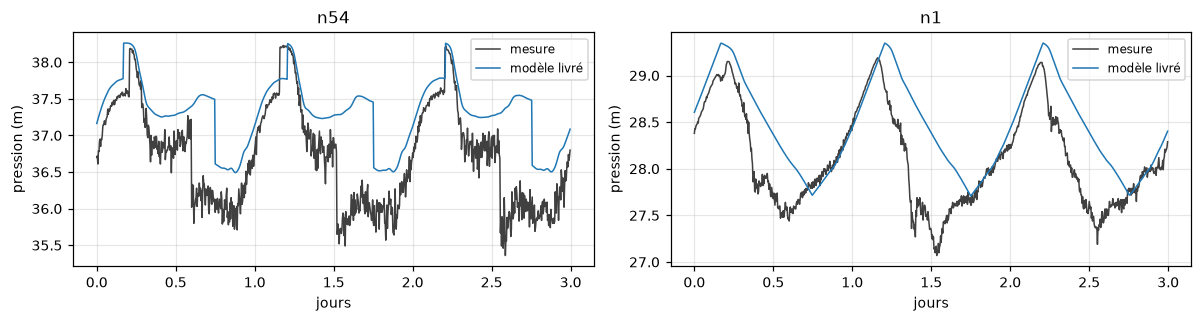

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
G.tracer_capteur(axes[0], S_livre, mesure, "n54", n_pas=3 * R.PAS_JOUR, etiquette="modèle livré")
G.tracer_capteur(axes[1], S_livre, mesure, "n1", n_pas=3 * R.PAS_JOUR, etiquette="modèle livré")
fig.tight_layout()

Le modèle suit la forme de la journée mais reste **décalé**. C'est un renseignement en soi, et il
justifie la section suivante.

## 2. La métrique : biais et dispersion, et pourquoi on les sépare

L'erreur d'un modèle se résume d'ordinaire par sa RMSE. Or elle se décompose exactement :

$$ \mathrm{RMSE}^2 = \mathrm{biais}^2 + \mathrm{dispersion}^2 $$

avec le biais la moyenne de l'erreur, et la dispersion son écart-type. C'est une identité, pas une
approximation — `diagnostics.resume` calcule la dispersion comme $\sqrt{\max(\mathrm{RMSE}^2 -
\mathrm{biais}^2,\ 0)}$.

Cette séparation n'est pas cosmétique, elle **change les conclusions** :

* le **biais** est un décalage constant. Il disparaît dans toute différence — entre deux instants,
  entre deux capteurs, entre aujourd'hui et la semaine dernière. Un détecteur qui compare ne le voit
  jamais ;
* la **dispersion** est ce qui reste une fois le décalage retiré. C'est elle qui masque un signal,
  et c'est donc elle qu'il faut juger.

Un levier qui divise la RMSE par deux en ne touchant que le biais n'a **rien** amélioré pour qui
cherche une anomalie. On verra au §8 que c'est exactement ce que fait l'ajustement des rugosités.

### Ce qu'on cherche à voir

Reste à savoir à quoi comparer ces mètres. La réponse n'est pas une opinion : on peut **poser une
fuite** dans le modèle et mesurer ce qu'elle produit aux capteurs.

Une fuite s'écrit dans EPANET comme un **émetteur** : un débit qui dépend de la pression au nœud,

$$ Q = C \cdot p^{\,0{,}5} $$

où $C$ est le coefficient à régler. Pour obtenir un débit visé $Q_0$ sous une pression de référence
$p_0$, il suffit donc de poser $C = Q_0 / \sqrt{p_0}$, en unités SI — c'est ce que fait
`reseau.coefficient_emetteur`.

> **Piège.** `wntr` expose aussi une méthode `add_leak`. Elle est **sans effet** sous le moteur
> EPANET : elle renseigne un attribut que seul le simulateur interne de `wntr` lit. Une fuite posée
> ainsi ne change rigoureusement rien aux pressions simulées. C'est vérifié par un test du dépôt.

In [7]:
# Trois conduites que le jeu de données perce en 2018, choisies pour encadrer le pire et le meilleur.
CIBLES = {"p257": "n350", "p232": "n184", "p538": "n531"}
JOUR = R.PAS_JOUR
D_j = D_livre[:JOUR + 1]

sans = R.pressions_simulees(D_j, noeuds, JOUR, tranche_jours=1,
                            niveau0=float(niveau[DEBUT]), verbeux=False)

# La pression au nœud percé sert à dimensionner l'émetteur : C = Q / sqrt(p), en unités SI.
p_cible = np.concatenate(R.simuler(
    D_j, noeuds, JOUR,
    lambda res, w, a, b: res.node["pressure"][list(CIBLES.values())].to_numpy()[:b - a],
    tranche_jours=1, niveau0=float(niveau[DEBUT]), verbeux=False))

lignes = []
for k, (conduite, noeud) in enumerate(CIBLES.items()):
    c = R.coefficient_emetteur(10.0, float(p_cible[:, k].mean()))
    avec = R.pressions_simulees(D_j, noeuds, JOUR, tranche_jours=1, niveau0=float(niveau[DEBUT]),
                                verbeux=False, fuites={noeud: c})
    baisse = (sans - avec).mean(axis=0)
    lignes.append({"conduite": conduite, "nœud percé": noeud,
                   "pression au nœud (m)": p_cible[:, k].mean(),
                   "baisse max (cm)": 100 * baisse.max(),
                   "capteur touché": capteurs["pressure"][int(baisse.argmax())],
                   "baisse médiane (cm)": 100 * np.median(baisse)})
print("une fuite de 10 m³/h, posée à trois endroits :")
print(pd.DataFrame(lignes).round(2).to_string(index=False))

une fuite de 10 m³/h, posée à trois endroits :
conduite nœud percé  pression au nœud (m)  baisse max (cm) capteur touché  baisse médiane (cm)
    p257       n350             26.680000            52.73             n1                 6.39
    p232       n184             46.889999            13.33           n613                 6.08
    p538       n531             54.619999             9.99           n506                 6.06


### Lecture

Voilà l'ordre de grandeur à garder en tête pour tout le carnet. Une fuite de 10 m³/h — de l'ordre
de 6 % de la consommation du réseau — déplace le capteur le plus proche de quelques centimètres à
quelques dizaines de centimètres **selon l'endroit où elle s'ouvre**, et laisse les autres capteurs
presque intacts.

À comparer aux **33 cm de dispersion** du modèle livré, mesurés juste au-dessus. Au meilleur
endroit la fuite fait une fois et demie l'erreur du modèle ; au pire elle en fait le tiers, et
aucun algorithme ne la retrouvera dans ces pressions-là. Et 10 m³/h n'est pas une petite fuite :
c'est 6 % de la consommation de toute la zone A+B.

Voilà le problème, en une ligne : **la détection est d'abord une affaire de rapport signal sur
bruit, pas d'algorithme.** Chaque centimètre d'erreur retiré au modèle est un centimètre de fuite
qui devient visible — c'est ce qui justifie tout le reste du carnet.

## 3. Équation (1) — décomposer un compteur

Premier volet de la calibration : la demande. On commence par les 82 jonctions où elle est
**mesurée**, et on décompose chaque compteur en un produit d'effets temporels :

$$ d(t) = \bar{d} \cdot T(t) \cdot S(t) \cdot R(t) $$

Quatre termes, et c'est un **produit** — retenez-le, car l'équation (2) sera une somme :

* $\bar{d}$ — la moyenne annuelle du compteur, en m³/h ;
* $T(t)$ — la **tendance** : une moyenne glissante centrée sur une fenêtre d'exactement une
  semaine. Cette largeur-là n'est pas un réglage : elle annule le cycle hebdomadaire, si bien que
  ce qui reste est la dérive lente, c'est-à-dire la saisonnalité annuelle ;
* $S(t)$ — le **profil hebdomadaire** : la moyenne de tous les « mardi 8 h 05 » de l'année, soit
  52 valeurs par créneau, sur le signal détendancé, renormalisée à une moyenne de 1. La médiane est
  disponible en option, plus robuste ; les deux coïncident sur un compteur propre et divergent là
  où il y a quelque chose à voir ;
* $R(t)$ — le **résidu**, que la méthode **jette**.

Jeter le résidu est le choix central, et il mérite d'être défendu. On ne cherche pas à prédire le
bruit de consommation d'un foyer — c'est impossible et ce serait inutile. On cherche la partie
**reproductible**, celle qu'on pourra transporter vers les nœuds sans compteur.

In [8]:
compteur = amr.sum().idxmax()          # le compteur le plus chargé, pour la lisibilité
creneaux = R.creneau(amr.index)        # à quel « mardi 8 h 05 » appartient chaque pas
d = P.decomposer(amr[compteur].to_numpy(), creneaux)

serie = amr[compteur].to_numpy()
var_expliquee = 1 - np.var(serie - d["lisse"]) / np.var(serie)
print(f"compteur {compteur} : d̄ = {d['moyenne']:.3f} m³/h")
print(f"part de la variance portée par d̄·T·S : {var_expliquee:.1%}")
print(f"médiane {np.median(serie):.2f} m³/h, maximum {serie.max():.2f}, "
      f"nul {np.mean(serie == 0):.0%} du temps")

compteur n25 : d̄ = 1.835 m³/h
part de la variance portée par d̄·T·S : 11.1%
médiane 0.35 m³/h, maximum 37.80, nul 10% du temps


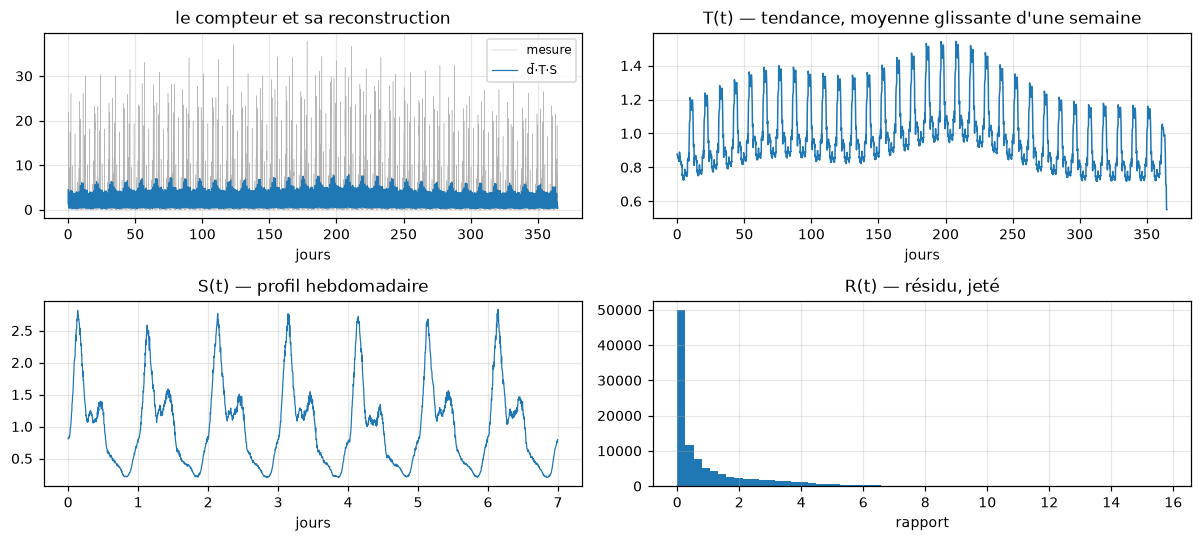

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 5.0))
j = np.arange(len(serie)) / R.PAS_JOUR

axes[0, 0].plot(j, serie, lw=0.3, color="0.7", label="mesure")
axes[0, 0].plot(j, d["lisse"], lw=0.8, label="d̄·T·S")
axes[0, 0].set_title("le compteur et sa reconstruction"); axes[0, 0].legend(fontsize=8)
axes[0, 1].plot(j, d["tendance"], lw=1.0)
axes[0, 1].set_title("T(t) — tendance, moyenne glissante d'une semaine")
axes[1, 0].plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR, d["saison"], lw=0.8)
axes[1, 0].set_title("S(t) — profil hebdomadaire"); axes[1, 0].set_xlabel("jours")
axes[1, 1].hist(d["residu"][np.isfinite(d["residu"])], bins=60)
axes[1, 1].set_title("R(t) — résidu, jeté"); axes[1, 1].set_xlabel("rapport")
for a in axes[0]: a.set_xlabel("jours")
fig.tight_layout()

### Un compteur seul est du bruit ; 82 compteurs sont un signal

La reconstruction n'explique qu'une fraction de la variance d'**un** compteur. Ce n'est pas un
échec de la méthode, c'est sa raison d'être : une consommation individuelle est faite de pointes,
et elle est largement aléatoire.

Mais le résidu d'un foyer est indépendant de celui du voisin. En sommant des dizaines de nœuds, les
résidus s'annulent entre eux, tandis que la tendance et le profil hebdomadaire, eux, **s'ajoutent**.
C'est vérifiable directement.

In [10]:
dec = P.decomposer_amr(ANNEE)          # applique l'équation (1) aux 82 compteurs (~15 s)

residu_total = (dec["mesure"].sum(axis=1) - dec["lisse"].sum(axis=1)).to_numpy()
var_tot = 1 - np.var(residu_total) / np.var(dec["mesure"].sum(axis=1).to_numpy())
var_unit = np.mean([1 - np.var(dec["mesure"][c].to_numpy() - dec["lisse"][c].to_numpy())
                    / np.var(dec["mesure"][c].to_numpy()) for c in dec["mesure"].columns])

print(f"variance portée par d̄·T·S, compteur par compteur : {var_unit:.1%}")
print(f"variance portée par d̄·T·S, sur la somme des 82    : {var_tot:.1%}")

variance portée par d̄·T·S, compteur par compteur : 42.1%
variance portée par d̄·T·S, sur la somme des 82    : 71.1%


amplitude restituée sur n25 seul : 34% de l'écart-type mesuré
amplitude restituée sur la somme des 82 : 85%


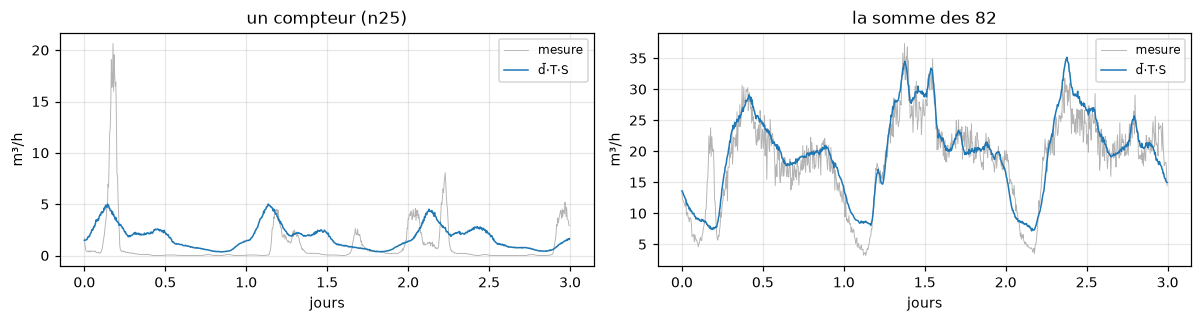

In [11]:
# La même reconstruction, à deux échelles. C'est toute la thèse de la section.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
t3 = slice(DEBUT, DEBUT + 3 * R.PAS_JOUR)
h = np.arange(3 * R.PAS_JOUR) / R.PAS_JOUR

axes[0].plot(h, amr[compteur].to_numpy()[t3], lw=0.6, color="0.7", label="mesure")
axes[0].plot(h, dec["lisse"][compteur].to_numpy()[t3], lw=1.0, label="d̄·T·S")
axes[0].set_title(f"un compteur ({compteur})")
axes[1].plot(h, dec["mesure"].sum(axis=1).to_numpy()[t3], lw=0.6, color="0.7", label="mesure")
axes[1].plot(h, dec["lisse"].sum(axis=1).to_numpy()[t3], lw=1.0, label="d̄·T·S")
axes[1].set_title("la somme des 82")
for a in axes:
    a.set_xlabel("jours"); a.set_ylabel("m³/h"); a.legend(fontsize=8)
fig.tight_layout()

un = np.std(dec["lisse"][compteur].to_numpy()) / np.std(amr[compteur].to_numpy())
somme = np.std(dec["lisse"].sum(axis=1).to_numpy()) / np.std(dec["mesure"].sum(axis=1).to_numpy())
print(f"amplitude restituée sur {compteur} seul : {un:.0%} de l'écart-type mesuré")
print(f"amplitude restituée sur la somme des 82 : {somme:.0%}")

C'est le même calcul, appliqué au même signal ; seule l'échelle change. Et c'est bien l'échelle qui
compte, puisqu'on va s'en servir pour alimenter des nœuds, pas pour prédire un foyer.

## 4. Équation (2) — des compteurs vers les 700 jonctions sans mesure

Il faut maintenant fabriquer une série pour les jonctions qui n'ont pas de compteur. L'idée de la
méthode est de ne pas les traiter comme interchangeables : le fichier de réseau attribue à chaque
jonction une demande de base **par type de consommateur** présent — résidentiel, commercial,
industriel. Un nœud où dominent les commerces n'a pas le même rythme qu'un nœud résidentiel.

$$ \hat{d}_i(t) = \sum_j \bar{d}_{ij} \cdot T_j(t) \cdot S_j(t) $$

> **Ne pas confondre les deux équations.** L'équation (1) est un **produit** : les effets temporels
> d'un même compteur se multiplient. L'équation (2) est une **somme** : les types de consommateurs
> d'un même nœud s'additionnent. C'est le contresens le plus facile à faire sur cette méthode.

Les poids $\bar{d}_{ij}$ sont donnés — ils sont dans le fichier. Ce sont les formes
$T_j \!\cdot\! S_j$ qu'il faut estimer, et on les obtient en résolvant cette même équation **à
l'envers** là où la mesure existe.

Avant d'inverser quoi que ce soit, regardons comment le fichier répartit réellement la demande
entre les trois types. C'est une lecture, pas une hypothèse, et elle change ce qu'on peut dire de
la suite.

In [12]:
zone = pd.Series(zones)
n_types = (bases > 0).sum(axis=1)

print("nombre de types de consommateurs par jonction :")
print(pd.crosstab(zone, n_types, rownames=["zone"], colnames=["types portés"]).to_string())
print("\ndemande nominale par zone et par type (m³/h) :")
print(bases.groupby(zone).sum().round(2).to_string())
industriels = list(bases.index[bases["Industrial"] > 0])
print(f"\nnœuds portant de l'industriel : {industriels}")
print(f"  tous en zone C et tous équipés d'un compteur : "
      f"{all(zones[n] == 'C' and n in amr.columns for n in industriels)}")

nombre de types de consommateurs par jonction :
types portés   0    1    2
zone                      
AB            35  102  553
C              0   84    8

demande nominale par zone et par type (m³/h) :
    Residential  Commercial  Industrial
AB        92.23       64.76        0.00
C         13.85        1.79        3.94

nœuds portant de l'industriel : ['n1', 'n4', 'n25', 'n347']
  tous en zone C et tous équipés d'un compteur : True


### Trois faits, et ils commandent la suite

**Aucune jonction ne porte les trois types.** 186 n'en portent qu'un, 561 en portent exactement
deux — toujours résidentiel + commercial — et 35 n'ont aucune demande. La somme de l'équation (2)
n'a donc jamais plus de deux termes.

**La demande industrielle vaut exactement zéro dans la zone A+B.** Elle n'existe que sur quatre
nœuds, tous en zone C, et tous équipés d'un compteur.

**Donc les 690 nœuds de A+B s'extrapolent avec deux formes seulement**, résidentielle et
commerciale. C'est important parce que la forme industrielle sera, on va le voir, la plus bruitée
des trois : estimée sur quatre compteurs, elle n'est en réalité **jamais transportée** vers un nœud
non mesuré. Le seul risque qu'elle fait courir est d'absorber du bruit au détriment des deux autres
pendant l'inversion, et le conditionnement de la matrice permet de le contrôler.

### L'inversion

Avec $W$ la matrice $82 \times 3$ des demandes nominales des nœuds équipés, et $A(t)$ le vecteur
des 82 séries lissées par l'équation (1), on résout à chaque pas

$$ W\, m(t) = A(t) $$

aux moindres carrés. En pratique la pseudo-inverse est calculée **une fois** et appliquée par un
seul produit matriciel : l'année entière coûte moins d'une seconde. Les formes obtenues sont
écrêtées à zéro — une demande négative n'a pas de sens — puis renormalisées à une moyenne de 1, de
sorte qu'elles se lisent comme des multiplicateurs de profil.

In [13]:
W = bases.loc[dec["lisse"].columns].to_numpy()          # 82 × 3
print(f"matrice W : {W.shape[0]} nœuds équipés × {W.shape[1]} types")
print(f"nœuds équipés portant chaque type : "
      f"{dict(zip(bases.columns, (W > 0).sum(axis=0)))}")
print(f"conditionnement de W : {np.linalg.cond(W):.2f}   "
      f"(1 = parfait, > 30 = inversion fragile)")

formes = P.formes_par_categorie(wn, ANNEE, dec)
print(f"\nformes obtenues : {formes.shape[0]} pas × {formes.shape[1]} types")

matrice W : 82 nœuds équipés × 3 types
nœuds équipés portant chaque type : {'Residential': np.int64(75), 'Commercial': np.int64(10), 'Industrial': np.int64(4)}
conditionnement de W : 4.01   (1 = parfait, > 30 = inversion fragile)

formes obtenues : 105120 pas × 3 types


rapport max/min sur l'année :
Residential    1.30
Commercial     1.32
Industrial     1.36

mois du maximum :
Residential         July
Commercial     September
Industrial          July


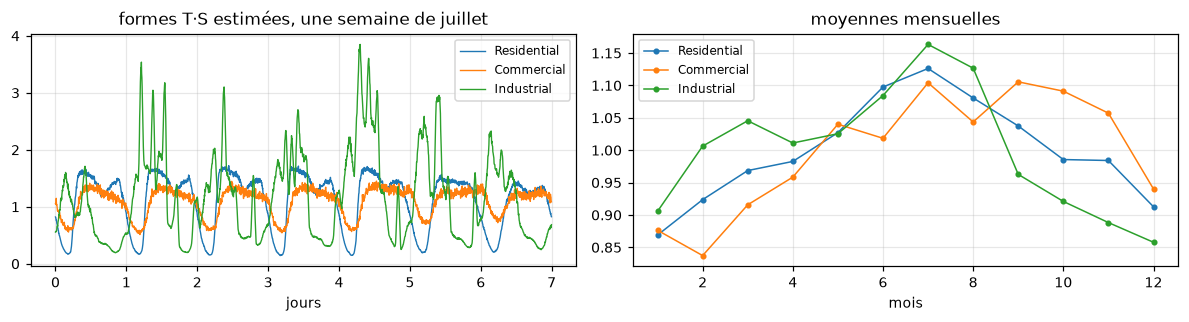

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.0))
sem = slice(DEBUT, DEBUT + R.PAS_SEMAINE)
for c in formes.columns:
    axes[0].plot(np.arange(R.PAS_SEMAINE) / R.PAS_JOUR, formes[c].to_numpy()[sem], lw=0.9, label=c)
axes[0].set_title("formes T·S estimées, une semaine de juillet"); axes[0].set_xlabel("jours")
mens = formes.resample("ME").mean()
for c in formes.columns:
    axes[1].plot(np.arange(12) + 1, mens[c].to_numpy(), marker="o", ms=3, lw=1.0, label=c)
axes[1].set_title("moyennes mensuelles"); axes[1].set_xlabel("mois")
for a in axes: a.legend(fontsize=8)
fig.tight_layout()

print("rapport max/min sur l'année :")
print((mens.max() / mens.min()).round(2).to_string())
print("\nmois du maximum :")
print(mens.idxmax().dt.strftime("%B").to_string())

### Lecture, et deux réserves

Les trois formes ont une saisonnalité d'**amplitude comparable**, un rapport max/min de 1,30 à
1,36, que le modèle livré n'avait pas du tout — ses profils sont strictement hebdomadaires. Ce qui
les distingue n'est pas l'amplitude mais la **phase** : le résidentiel culmine en juillet, le
commercial en septembre. Deux mois d'écart, et c'est là l'information que porte le mélange.

**Première réserve : le profil industriel n'est pas un résultat.** Il est estimé sur 4 nœuds
équipés seulement — contre 75 pour le résidentiel et 10 pour le commercial — et c'est pourtant la
forme la plus agitée des trois. Ce n'est pas un signal industriel, c'est le bruit de quatre
compteurs. Ce qui limite les dégâts est le fait établi plus haut : ces quatre nœuds sont les seuls
du réseau à porter de l'industriel, et ils sont tous mesurés.

**Seconde réserve : ces formes sont estimées sur une zone et appliquées à une autre.** 82 compteurs
en zone C, 690 jonctions dans A+B. Rien dans les données ne garantit que les habitudes de
consommation y soient les mêmes. Cette réserve-là est sérieuse — et c'est la seule du carnet qu'on
pourra **lever par la mesure**, au §6.

Une limite de reproduction, aussi, qu'il vaut mieux énoncer : la publication d'origine part de
valeurs par groupe fondées sur le matériau et l'âge des conduites, informations qui ne figurent pas
dans le fichier dont on dispose. Ce carnet fait donc au mieux avec ce qui est lisible.

In [15]:
D_annee, noeuds_c = P.demandes_calibrees(wn, ANNEE, formes)     # 105 120 × 782, 330 Mo
assert noeuds_c == noeuds
print(f"demandes calibrées : {D_annee.shape[0]} pas × {D_annee.shape[1]} jonctions, "
      f"{D_annee.nbytes / 1e6:.0f} Mo en {D_annee.dtype}")
print(f"demande totale du réseau : {D_annee.sum(axis=1, dtype=float).mean():.1f} m³/h en moyenne")

demandes calibrées : 105120 pas × 782 jonctions, 329 Mo en float32
demande totale du réseau : 176.6 m³/h en moyenne


## 5. La zone C — là où la demande est mesurée nœud par nœud

Le modèle qu'on vient de construire applique l'équation (2) aux **782** jonctions, sans exception.
Y compris aux 82 dont la série est connue pas par pas. C'est une perte sèche : sur ces nœuds-là,
aucune forme estimée ne vaudra jamais la mesure.

On les remet donc à leur valeur lue. Les 10 jonctions de la zone C sans compteur gardent leur
demande modélisée — leur nominal cumulé ne pèse que 1,84 m³/h.

In [16]:
n_c = [n for n, z in zones.items() if z == "C"]
sans_compteur = [n for n in n_c if n not in amr.columns]
nominal = bases.sum(axis=1)

print(f"zone C : {len(n_c)} jonctions, dont {len(amr.columns)} équipées d'un compteur")
print(f"demande nominale des {len(amr.columns)} équipées     : {nominal[list(amr.columns)].sum():.2f} m³/h")
print(f"demande nominale des {len(sans_compteur)} non équipées : {nominal[sans_compteur].sum():.2f} m³/h")
print(f"facteur d'extrapolation des compteurs à la zone : "
      f"×{nominal[n_c].sum() / nominal[list(amr.columns)].sum():.4f}")

zone C : 92 jonctions, dont 82 équipées d'un compteur
demande nominale des 82 équipées     : 17.74 m³/h
demande nominale des 10 non équipées : 1.84 m³/h
facteur d'extrapolation des compteurs à la zone : ×1.1038


In [17]:
fen = slice(DEBUT, DEBUT + N_PAS + 1)
D_modele = D_annee[fen]                                          # équation (2) partout
D_mesure = A.injecter_compteurs(D_modele, noeuds, ANNEE, debut=DEBUT)   # zone C mesurée

est_c = np.array([zones[n] == "C" for n in noeuds])
est_ab = ~est_c
print(f"zone C sur la semaine, demande modélisée : {D_modele[:, est_c].sum(axis=1).mean():.2f} m³/h")
print(f"zone C sur la semaine, demande mesurée   : {D_mesure[:, est_c].sum(axis=1).mean():.2f} m³/h")
print(f"erreur du modèle sur le total de la zone : "
      f"{D_modele[:, est_c].sum(axis=1).mean() / D_mesure[:, est_c].sum(axis=1).mean() - 1:+.1%}")

zone C sur la semaine, demande modélisée : 22.02 m³/h
zone C sur la semaine, demande mesurée   : 21.66 m³/h
erreur du modèle sur le total de la zone : +1.7%


### Le bilan de masse de la zone C : un débitmètre de fuite gratuit

La zone C a une propriété que le reste du réseau n'a pas : **toute sa frontière est instrumentée**.
Elle est alimentée uniquement par le réservoir T1, lui-même rempli uniquement par la pompe. Trois
instruments en font le tour, et ils existent tous :

* le **débitmètre de la pompe**, pour ce qui entre ;
* le **capteur de niveau** de T1, pour ce qui est stocké ;
* les **82 compteurs**, pour ce qui est consommé.

Si l'on connaît tout ce qui entre, tout ce qui est consommé et tout ce qui est stocké, alors ce qui
manque à l'appel **fuit**. Attention : ce qui entre dans la zone n'est pas le débit de la pompe,
puisqu'une partie reste dans le réservoir. C'est

$$ Q_{\text{entrée}} = Q_{\text{pompe}} - A \cdot \frac{\mathrm{d}h}{\mathrm{d}t} $$

avec $A$ la section du réservoir et $h$ son niveau, lu au capteur.

In [18]:
bilan = A.bilan_zone_c(wn, ANNEE)
section = R.section_reservoir(wn)

print(f"section du réservoir : {section:.0f} m²")
print(f"débit de la pompe    : {debits['PUMP_1'].mean():.1f} m³/h en moyenne sur l'année")
print(f"entrée en zone C     : {bilan['entre_m3h'].mean():.1f} m³/h")
print(f"consommation         : {bilan['consomme_m3h'].mean():.2f} m³/h")
print(f"reste, donc fuite    : {bilan['fuite_m3h'].mean():.2f} m³/h "
      f"({bilan['fuite_m3h'].mean() / bilan['entre_m3h'].mean():.0%} de ce qui entre)")

section du réservoir : 201 m²
débit de la pompe    : 26.8 m³/h en moyenne sur l'année
entrée en zone C     : 26.8 m³/h
consommation         : 19.43 m³/h
reste, donc fuite    : 7.41 m³/h (28% de ce qui entre)


conduites fuyardes situées en zone C : ['p31', 'p257']



corrélation            : 0.9981
décalage moyen (biais) : +0.08 m³/h
bruit (écart-type)     : 0.23 m³/h


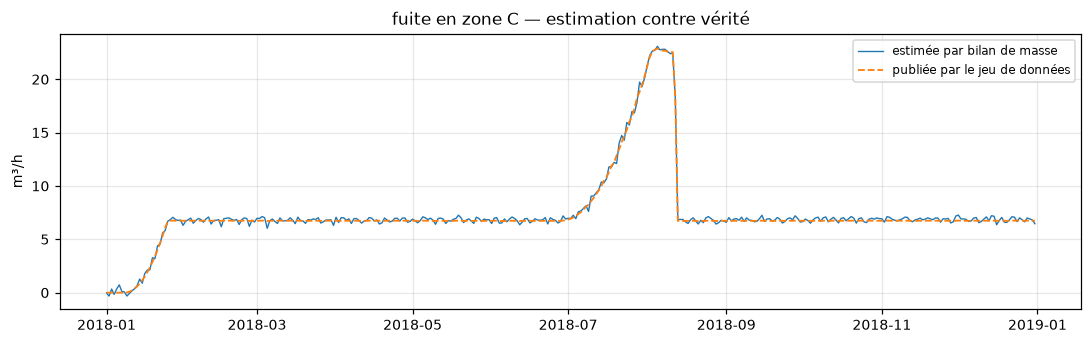

In [19]:
# Contrôle : le jeu de données publie ses fuites. On ne s'en sert nulle part pour calibrer —
# uniquement ici, pour vérifier. Deux des quatorze conduites fuyardes de 2018 sont en zone C.
fuites = R.charger_fuites(ANNEE)
en_c = [p for p in fuites.columns
        if zones.get(wn.get_link(p).start_node_name) == "C"
        and zones.get(wn.get_link(p).end_node_name) == "C"]
publiee = fuites[en_c].sum(axis=1)
estimee = bilan["fuite_m3h"]
print("conduites fuyardes situées en zone C :", en_c)

fig, ax = plt.subplots()
ax.plot(estimee.resample("D").mean(), lw=0.9, label="estimée par bilan de masse")
ax.plot(publiee.resample("D").mean(), lw=1.2, ls="--", label="publiée par le jeu de données")
ax.set_ylabel("m³/h"); ax.legend(fontsize=8)
ax.set_title("fuite en zone C — estimation contre vérité")
fig.tight_layout()

e, v = estimee.resample("D").mean(), publiee.resample("D").mean()
print(f"\ncorrélation            : {e.corr(v):.4f}")
print(f"décalage moyen (biais) : {(e - v).mean():+.2f} m³/h")
print(f"bruit (écart-type)     : {(e - v).std():.2f} m³/h")

In [20]:
# À quelle finesse peut-on lire ? Tout dépend de la durée sur laquelle on moyenne.
lignes = []
for lib, regle in [("5 minutes", None), ("1 heure", "h"), ("1 jour", "D"), ("1 semaine", "W")]:
    a = estimee if regle is None else estimee.resample(regle).mean()
    b = publiee if regle is None else publiee.resample(regle).mean()
    lignes.append({"moyenné sur": lib, "biais (m³/h)": (a - b).mean(),
                   "bruit (m³/h)": (a - b).std(),
                   "plus petite fuite lisible à 3σ": 3 * (a - b).std()})
print(pd.DataFrame(lignes).round(2).to_string(index=False))

moyenné sur  biais (m³/h)  bruit (m³/h)  plus petite fuite lisible à 3σ
  5 minutes          0.08         10.36                           31.07
    1 heure          0.08          1.96                            5.87
     1 jour          0.08          0.23                            0.68
  1 semaine          0.07          0.08                            0.23


### Lecture

**Le bilan retrouve les fuites publiées presque exactement** — corrélation 0,998, biais de
0,08 m³/h, bruit de 0,23 m³/h sur des moyennes journalières — alors qu'il n'a jamais vu la réponse
et qu'aucun modèle hydraulique n'est intervenu. C'est une soustraction entre trois instruments.

Le bruit vient presque entièrement de l'**arrondi du capteur de niveau**, qui n'a que deux
décimales : un centimètre d'arrondi multiplié par 201 m² vaut déjà 24 m³/h au pas de 5 minutes.
Il se moyenne, d'où le tableau : 31 m³/h à 5 minutes, **0,7 m³/h sur une journée**, 0,2 sur une
semaine.

À comparer à la route par les pressions, mesurée au §2 : une fuite de 10 m³/h y déplaçait le
capteur le plus proche de 53 cm au meilleur endroit et de 10 cm au pire, pour une dispersion de
modèle de 33 cm — autrement dit, invisible dans deux cas sur trois. Le bilan de masse voit
**0,7 m³/h partout dans la zone C**, sans dépendre de la distance à un capteur, et **sans demander
le moindre modèle calibré**. Un facteur quinze, et la fin de la dépendance au modèle. Là où la frontière est instrumentée, la soustraction bat la simulation.

## 6. La zone A+B — la demande globale se déduit, et c'est un piège

On aimerait faire pareil sur les 690 autres jonctions. Les deux débitmètres d'entrée donnent tout
ce qui entre dans le réseau, et on vient de calculer ce qui part vers la zone C. La différence sort
donc forcément par A+B :

$$ Q_{\text{A+B}} = Q_{p227} + Q_{p235} - Q_{\text{PUMP\_1}} $$

C'est une mesure directe, à chaque pas, et aucun modèle de demande ne battra une mesure. La
tentation est donc de **recaler** le modèle dessus. Regardons d'abord ce que cette différence
contient réellement.

In [21]:
sortie_ab = A.demande_ab_mesuree(ANNEE)                  # p227 + p235 − PUMP_1
fuite_ab = fuites[[p for p in fuites.columns if p not in en_c]].sum(axis=1)

print(f"tout ce qui sort par A+B   : {sortie_ab.mean():.1f} m³/h")
print(f"  dont fuites (publiées)   : {fuite_ab.mean():.1f} m³/h  "
      f"({fuite_ab.mean() / sortie_ab.mean():.0%})")
print(f"  dont consommation réelle : {sortie_ab.mean() - fuite_ab.mean():.1f} m³/h")

tout ce qui sort par A+B   : 174.9 m³/h
  dont fuites (publiées)   : 18.2 m³/h  (10%)
  dont consommation réelle : 156.7 m³/h


**Le bilan brut mesure ce qui sort, pas ce qui est consommé.** Un dixième de cette eau ne va à
personne : elle fuit. Recaler la demande du modèle sur ce bilan-**là** reviendrait à répartir
18 m³/h de fuite sur 690 nœuds, comme si c'était de la consommation.

Ce défaut n'a rien de fatal, et il saute aux yeux : puisque le jeu de données publie ses fuites,
il suffit de les retrancher pour obtenir la consommation seule. C'est ce qu'on fait deux cellules
plus bas, et la section qui suit la lecture du tableau mesure ce que cette cible change vraiment.

Est-ce grave ? Cela dépend entièrement de ce qu'on veut faire du modèle — et pour trancher, il faut
savoir si le modèle de demande, lui, était juste. Le jeu de données permet de le vérifier, puisqu'il
publie ses fuites. C'est le contrôle le plus sévère qu'on puisse faire subir à l'équation (2) : les
82 compteurs sont **tous en zone C**, qui ne porte que 11 % de la demande ; on va leur demander de
prédire la consommation de 690 nœuds qu'ils n'ont jamais vus.

In [22]:
modele_ab = pd.Series(D_annee[:len(horo), est_ab].sum(axis=1, dtype=float), index=horo)
reel_ab = sortie_ab - fuite_ab                            # la consommation réelle de A+B

print("moyennes sur l'année, zone A+B :")
print(f"  modèle de demande (équation 2) : {modele_ab.mean():.1f} m³/h")
print(f"  bilan des débitmètres, brut    : {sortie_ab.mean():.1f} m³/h")
print(f"  bilan moins fuites publiées    : {reel_ab.mean():.1f} m³/h")
print(f"\nécart du modèle au bilan brut    : {modele_ab.mean() / sortie_ab.mean() - 1:+.1%}")
print(f"écart du modèle à la consommation: {modele_ab.mean() / reel_ab.mean() - 1:+.1%}")

moyennes sur l'année, zone A+B :
  modèle de demande (équation 2) : 157.0 m³/h
  bilan des débitmètres, brut    : 174.9 m³/h
  bilan moins fuites publiées    : 156.7 m³/h

écart du modèle au bilan brut    : -10.2%
écart du modèle à la consommation: +0.2%


            modèle  bilan brut  bilan − fuites
2018-01-31   136.9       136.8           136.7
2018-02-28   139.4       150.8           139.0
2018-03-31   148.7       186.3           148.5
2018-04-30   152.7       156.1           152.2
2018-05-31   162.1       201.1           161.7
2018-06-30   167.2       180.6           166.9
2018-07-31   175.4       180.0           174.8
2018-08-31   167.3       186.8           166.5
2018-09-30   167.3       179.0           166.9
2018-10-31   161.6       194.0           161.2
2018-11-30   159.2       181.8           159.1
2018-12-31   145.1       162.8           145.5


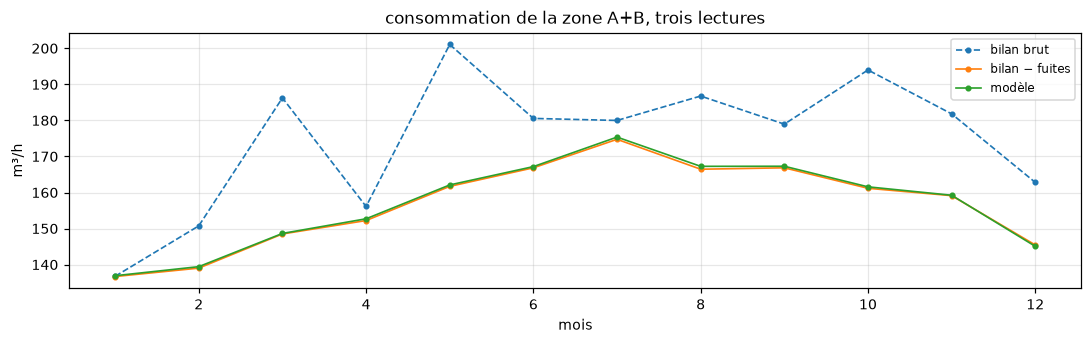

In [23]:
tab = pd.DataFrame({"modèle": modele_ab, "bilan brut": sortie_ab,
                    "bilan − fuites": reel_ab}).resample("ME").mean()
print(tab.round(1).to_string())

fig, ax = plt.subplots()
for col, st in [("bilan brut", "--"), ("bilan − fuites", "-"), ("modèle", "-")]:
    ax.plot(np.arange(12) + 1, tab[col].to_numpy(), st, marker="o", ms=3, lw=1.1, label=col)
ax.set_xlabel("mois"); ax.set_ylabel("m³/h"); ax.legend(fontsize=8)
ax.set_title("consommation de la zone A+B, trois lectures")
fig.tight_layout()

### Lecture — la seconde réserve du §4 est levée

**Le modèle de demande est juste.** Il ne s'écarte de la consommation réelle de A+B que de deux
dixièmes de pour cent sur l'année, et il suit la courbe corrigée **mois par mois à moins d'un m³/h**,
douze mois sur douze — sans qu'on lui ait jamais montré une mesure de cette zone.

Le tableau raconte l'année en creux. En janvier, modèle et bilan brut coïncident à 0,1 m³/h près :
il n'y a pas encore de fuite. Puis l'écart s'ouvre — 38 en mars, 39 en mai, 32 en octobre — et se
referme quand une réparation a lieu. **Ce qui sépare les deux courbes n'est pas l'erreur du modèle,
c'est le débit de fuite du mois.**

Autrement dit : des formes horaires extraites de 82 compteurs situés **tous dans l'autre zone**,
appliquées à 690 nœuds non mesurés avec pour seul guide les demandes nominales du fichier,
retrouvent la consommation de la zone à moins d'un pour cent. L'extrapolation d'une zone à l'autre,
qui était l'hypothèse la plus fragile de la méthode, **est validée par la mesure**.

Et cela retourne la question du recalage. Le modèle de demande n'a pas besoin d'être recalé : il est
déjà juste. Le recaler sur le bilan brut ne corrigerait pas une erreur, cela **ajouterait** 18 m³/h
de fuite là où il n'y en avait pas.

> **Décision, et elle structure tout ce qui suit.** On ne recale pas la demande de A+B sur le bilan
> **brut**, qui contient les fuites. Sur le bilan **moins les fuites**, on peut et on le fera — la
> section suivante montre que cela ne change rien, parce qu'il n'y a rien à changer. Le §9 mesure
> ensuite ce que le recalage brut coûte et ce qu'il rapporte : il améliore bel et bien les
> pressions, et ce n'est pas contradictoire.

### « On connaît les fuites — pourquoi ne pas simplement les retirer du bilan ? »

C'est la bonne objection, et il faut y répondre franchement : **elle est juste, et on le fait.**
L'égalité de conservation est exacte à chaque pas,

$$ \underbrace{Q_{p227} + Q_{p235} - Q_{\mathrm{PUMP\_1}}}_{\text{mesuré}}
   \;=\; \underbrace{Q_{\text{conso}}(t)}_{\text{ce qu'on cherche}} \;+\; Q_{\text{fuites}}(t) $$

et le fichier de fuites donne $Q_{\text{fuites}}(t)$ conduite par conduite. On retranche des deux
côtés, et on obtient la consommation réelle de la zone A+B, pas par pas. C'est exactement la
colonne `bilan − fuites` du tableau ci-dessus, et c'est elle qui sert de cible au §10 pour
construire la variante **« détection, cible sans fuites »**.

Il n'y a donc **aucun obstacle de principe**, et le carnet ne s'en prive pas. Deux remarques
seulement, et ce sont des remarques sur l'usage, pas sur la validité :

1. cette cible demande de connaître les fuites de l'année **avant** de calibrer. Sur 2018 c'est
   possible parce que le jeu de données les publie ; sur 2019, l'année qu'on veut justement
   surveiller, elle n'existe pas. C'est donc un **étalon** — la meilleure cible imaginable — et non
   une méthode reproductible ;
2. reste à savoir ce qu'elle **change**. Le recalage ne remplace pas le modèle : il multiplie,
   semaine par semaine, la demande des 690 nœuds par un scalaire qui amène leur somme sur la cible.
   Ce scalaire est donc la mesure exacte de ce que la cible a à corriger. Regardons-le.

In [ ]:
# Le multiplicateur hebdomadaire que `recaler_zone_ab` appliquerait aux 690 nœuds de A+B,
# selon qu'on lui donne le bilan brut ou le bilan débarrassé des fuites publiées.
semaine = R.PAS_SEMAINE
tranches = range(0, len(modele_ab), semaine)
mult = pd.DataFrame({
    "cible sans fuites": [np.nansum(reel_ab.iloc[a:a + semaine]) / modele_ab.iloc[a:a + semaine].sum()
                          for a in tranches],
    "cible bilan brut":  [np.nansum(sortie_ab.iloc[a:a + semaine]) / modele_ab.iloc[a:a + semaine].sum()
                          for a in tranches]})

print(f"{len(mult)} semaines — facteur appliqué à la demande des 690 nœuds :")
print(mult.describe().loc[["mean", "std", "min", "max"]].round(4).to_string())
print()
for c in mult:
    d = (mult[c] - 1).abs()
    print(f"  {c:18s} correction médiane {np.median(d) * modele_ab.mean():6.2f} m³/h"
          f"   ({np.median(d):.2%})")

53 semaines — facteur appliqué à la demande des 690 nœuds :
      cible sans fuites  cible bilan brut
mean             1.0003            1.1161
std              0.0197            0.1030
min              0.9939            0.9955
max              1.1398            1.4338

  cible sans fuites  correction médiane   0.50 m³/h   (0.32%)
  cible bilan brut   correction médiane  17.04 m³/h   (10.85%)

### Lecture — la cible propre est juste, et elle n'a rien à corriger

Les deux colonnes disent toute l'histoire.

**Avec la cible sans fuites, le facteur vaut 1.** Moyenne 1,0003, correction médiane de 0,50 m³/h
sur 157 — trois dixièmes de pour cent. Le recalage est mathématiquement irréprochable et
opérationnellement **vide** : il multiplie la demande par un nombre qui vaut un. C'est la raison
pour laquelle, au §10, les lignes « détection » et « détection, cible sans fuites » se départagent
à la quatrième décimale. Non pas parce que la soustraction serait fausse ou interdite, mais parce
que **le modèle de demande était déjà sur la cible**.

**Avec le bilan brut, le facteur vaut 1,12.** Correction médiane de 17 m³/h, et jusqu'à ×1,43 sur
la pire semaine. Ces 17 m³/h ne sont pas une erreur du modèle qu'on corrigerait : ce sont les
fuites, qu'on verse dans la demande de 690 nœuds qui ne les consomment pas.

> **La conclusion n'est donc pas « on ne retire pas les fuites ».** C'est : *retirer les fuites est
> la bonne chose à faire, et quand on le fait correctement on constate qu'il n'y avait rien à
> retirer au modèle.* La soustraction sert alors à **prouver** le modèle de demande plutôt qu'à le
> corriger — et c'est un résultat plus fort que si elle l'avait amélioré, puisqu'un modèle qu'on
> peut reconstruire sans le fichier de fuites reste utilisable en 2019.

Une semaine fait exception, à ×1,14 sur la cible propre. C'est le seul endroit de l'année où la
consommation réelle s'écarte vraiment du modèle ; le fichier de fuites n'est pas garanti exhaustif,
et l'écart peut aussi bien être une fuite non publiée qu'un défaut du modèle. On ne tranche pas.

### Et pour détecter une fuite dans A+B ?

Le bilan y donne « fuites + consommation » sans moyen de séparer les deux : il n'y a pas un seul
compteur dans la zone. La ligne du dessus a bien séparé les deux, mais en lisant la réponse dans le
fichier de fuites — légitime pour **valider** sur 2018, absurde pour **détecter**, et impossible
l'année suivante.

La méthode classique pour s'en sortir est le **débit de nuit minimal** : vers 3 heures du matin la
consommation est au plus bas, donc ce qui coule encore est surtout de la fuite. Mesurons ce qu'elle
vaut ici.

In [24]:
nuit = sortie_ab.between_time("02:00", "04:00").resample("D").min()
t = pd.DataFrame({"nuit": nuit, "fuite": fuite_ab.resample("D").mean()}).dropna()
pente, ordonnee = np.polyfit(t.fuite, t.nuit, 1)

print(f"corrélation débit de nuit / fuite publiée : {t.nuit.corr(t.fuite):.3f}")
print(f"régression : nuit = {pente:.2f} × fuite + {ordonnee:.0f}")
print(f"reste après régression : {(t.nuit - (pente * t.fuite + ordonnee)).std():.1f} m³/h de bruit")

corrélation débit de nuit / fuite publiée : 0.885
régression : nuit = 1.04 × fuite + 50
reste après régression : 9.1 m³/h de bruit


La pente vaut 1,04 : le débit de nuit **suit** la fuite, un mètre cube pour un mètre cube.
L'ordonnée à l'origine, une cinquantaine de m³/h, est la consommation nocturne incompressible de la
zone. La méthode fonctionne donc — mieux qu'on ne pourrait le craindre.

Mais il reste **9 m³/h de bruit** après régression, là où le bilan de la zone C en laissait 0,23 sur
des moyennes journalières. Un facteur quarante. Une fuite de 5 m³/h, parfaitement lisible en
zone C, est ici sous le bruit ; il en faut une trentaine pour ressortir à 3σ. La méthode classique
n'est donc pas inutilisable sur A+B : elle y est simplement **quarante fois moins sensible**, et
elle ne dit rien de l'endroit.

**Le découpage compte donc plus que la méthode.** La même soustraction donne un résultat exploitable
sur 11 % du réseau et rien du tout sur les 89 % restants. La différence n'est pas dans le calcul,
elle est dans l'emplacement des capteurs.

## 7. Les conditions aux limites — deux capteurs, aucun ajustement

On a traité la demande. Reste ce que le réseau **reçoit** et ce qu'il **stocke**, c'est-à-dire ses
conditions aux limites. C'est la partie du modèle dont on parle le moins et qui, on va le voir,
rapporte le plus.

### La pompe suit une consigne, pas la réalité

Le fichier pilote la pompe par deux contrôles sur le niveau du réservoir :

```
LINK PUMP_1 CLOSED IF NODE T1 ABOVE 3.9000
LINK PUMP_1 OPEN   IF NODE T1 BELOW 2.4000
```

C'est une règle plausible, et c'est une **hypothèse**. La vraie pompe est commandée autrement, et
son débit est mesuré : on peut donc comparer l'hypothèse à la réalité plutôt que de la supposer.

In [25]:
statut = A.statut_pompe(ANNEE)          # 1 quand le débitmètre de la pompe dépasse 1 m³/h

def statut_simule(n=N_PAS):
    # relit l'état de la pompe décidé par les contrôles du fichier
    return np.concatenate(R.simuler(
        D_mesure[:n + 1], noeuds, n,
        lambda res, w, a, b: res.link["status"]["PUMP_1"].to_numpy()[:b - a],
        tranche_jours=7, niveau0=float(niveau[DEBUT]), verbeux=False))

st_sim, st_mes = statut_simule(), statut[DEBUT:DEBUT + N_PAS]
print(f"pompe en marche : {st_mes.mean():.1%} du temps mesuré, {st_sim.mean():.1%} simulé")
print(f"basculements sur la fenêtre : {len(A.transitions(st_mes))} mesurés, "
      f"{len(A.transitions(st_sim))} simulés")
print(f"états en désaccord : {np.mean(st_mes != st_sim):.1%} des pas")

pompe en marche : 65.0% du temps mesuré, 48.1% simulé
basculements sur la fenêtre : 14 mesurés, 14 simulés
états en désaccord : 21.4% des pas


In [26]:
# Combien vaut la pompe, en mètres de pression ? Réponse lue dans les mesures, sans modèle.
p_mes = R.charger_pressions(ANNEE).to_numpy()
marche = statut.astype(bool)
entrant = (debits["p227"] + debits["p235"]).to_numpy()

print(f"débit entrant : {entrant[marche].mean():.0f} m³/h pompe en marche, "
      f"{entrant[~marche].mean():.0f} m³/h à l'arrêt "
      f"(+{100 * (entrant[marche].mean() / entrant[~marche].mean() - 1):.0f} %)")
print(f"la pompe prélève à elle seule {debits['PUMP_1'][marche].mean():.0f} m³/h, soit "
      f"{100 * debits['PUMP_1'][marche].mean() / entrant[marche].mean():.0f} % de ce qui entre")
print(f"\npression moyenne aux 33 capteurs : {p_mes[marche].mean():.3f} m en marche, "
      f"{p_mes[~marche].mean():.3f} m à l'arrêt (écart {p_mes[marche].mean() - p_mes[~marche].mean():+.3f} m)")
ecart = pd.Series(p_mes[marche].mean(axis=0) - p_mes[~marche].mean(axis=0), index=capteurs["pressure"])
print("\ncapteurs les plus sensibles à l'état de la pompe :")
print(ecart.sort_values().head(4).round(3).to_string())

débit entrant : 217 m³/h pompe en marche, 178 m³/h à l'arrêt (+22 %)
la pompe prélève à elle seule 44 m³/h, soit 20 % de ce qui entre

pression moyenne aux 33 capteurs : 46.099 m en marche, 46.452 m à l'arrêt (écart -0.353 m)

capteurs les plus sensibles à l'état de la pompe :
n54    -0.913
n410   -0.781
n429   -0.772
n342   -0.582


### Lecture

Le modèle se trompe d'état de pompe **un peu plus d'un pas sur cinq**, et pourtant le nombre de
basculements est le bon — 14 contre 14. Ce n'est donc pas la fréquence qui cloche, c'est le
**moment** et la **durée** : la vraie pompe tourne 65 % du temps, la simulée 48 %.

Le mécanisme est mesuré, pas supposé. La pompe n'est pas un détail du réservoir : elle prélève un
cinquième de tout ce qui entre dans le réseau. Quand elle démarre, le débit dans les conduites de
transport augmente d'autant, la perte de charge le long de ces conduites augmente avec, et
**toutes** les pressions descendent — d'un tiers de mètre en moyenne, de près d'un mètre sur les
capteurs proches de l'arrivée.

Se tromper d'état un pas sur cinq revient donc à injecter cet écart dans le résidu un pas sur cinq,
avec le signe qui va bien. C'est du même ordre que l'erreur totale qu'on cherche à expliquer.

Le remède ne demande aucun modèle : on retire les deux contrôles et on les remplace par le profil
d'état **lu au débitmètre**.

### Mais alors le réservoir se bloque

Retirer les contrôles retire aussi la seule chose qui régulait le niveau du réservoir. La pompe
étant désormais commandée de l'extérieur, le niveau devient l'**intégrale libre** de l'écart entre
ce qui entre et ce que le modèle croit consommer. Une petite erreur de demande, constante,
s'accumule — et finit par coller le réservoir au trop-plein.

Le remède est du même genre : le niveau est mesuré, donc on **réancre** chaque tranche de
simulation sur la mesure. Un seul paramètre, la durée de la tranche.

mesuré                     : de 2.39 à 3.90 m
sans ancrage               : de 2.84 à 4.00 m, saturé sur 20% des pas, écart moyen au capteur 0.49 m
réancré chaque jour        : de 2.56 à 4.00 m, saturé sur  9% des pas, écart moyen au capteur 0.37 m
réancré toutes les 6 h     : de 2.39 à 4.00 m, saturé sur  2% des pas, écart moyen au capteur 0.11 m


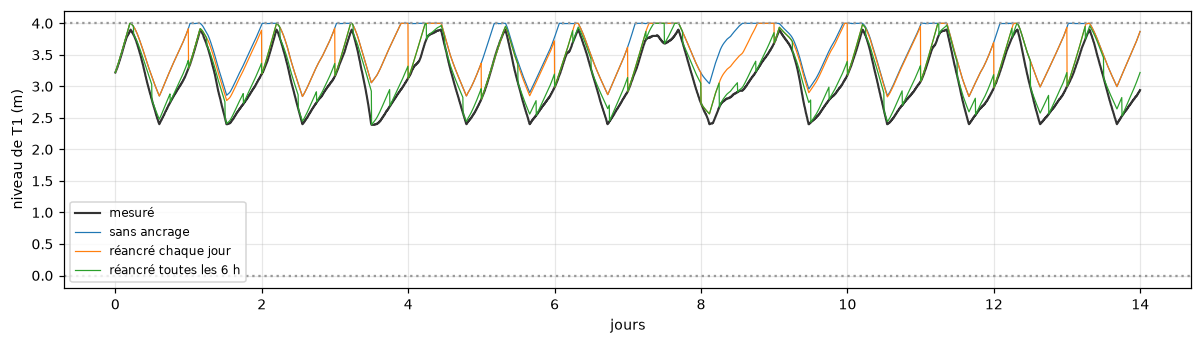

In [27]:
def niveau_simule(tranche, ancrage, n=14 * R.PAS_JOUR):
    kw = dict(pompe=statut[DEBUT:DEBUT + n + 1])
    if ancrage:
        kw["niveau_mesure"] = niveau[DEBUT:DEBUT + n + 1]
    return np.concatenate(R.simuler(
        D_annee[DEBUT:DEBUT + n + 1], noeuds, n,
        lambda res, w, a, b: (res.node["head"]["T1"].to_numpy()[:b - a]
                              - w.get_node("T1").elevation),
        tranche_jours=tranche, niveau0=float(niveau[DEBUT]), verbeux=False, **kw))

variantes_niv = {"sans ancrage": niveau_simule(14, False),
                 "réancré chaque jour": niveau_simule(1, True),
                 "réancré toutes les 6 h": niveau_simule(0.25, True)}
vrai = niveau[DEBUT:DEBUT + 14 * R.PAS_JOUR]

fig, ax = plt.subplots(figsize=(11, 3.2))
j = np.arange(len(vrai)) / R.PAS_JOUR
ax.plot(j, vrai, lw=1.4, color="0.2", label="mesuré")
for nom, h in variantes_niv.items():
    ax.plot(j, h[:len(vrai)], lw=0.8, label=nom)
ax.axhline(0, ls=":", color="0.6"); ax.axhline(4.0, ls=":", color="0.6")
ax.set_xlabel("jours"); ax.set_ylabel("niveau de T1 (m)"); ax.legend(fontsize=8)
fig.tight_layout()

print(f"{'mesuré':26s} : de {vrai.min():.2f} à {vrai.max():.2f} m")
for nom, h in variantes_niv.items():
    h = h[:len(vrai)]
    print(f"{nom:26s} : de {h.min():.2f} à {h.max():.2f} m, "
          f"saturé sur {np.mean((h <= 0.001) | (h >= 3.999)):3.0%} des pas, "
          f"écart moyen au capteur {np.abs(h - vrai).mean():.2f} m")

Sans ancrage, le niveau part et vient **buter contre le trop-plein**, où il reste collé une bonne
partie du temps. Un réservoir saturé ne joue plus son rôle : il absorbe ou fournit ce qu'on veut
sans que son niveau bouge, et la zone qu'il alimente devient fausse.

L'ancrage ne supprime pas la saturation, il la **borne** : plus les tranches sont courtes, moins
l'erreur a le temps de s'accumuler, et le prix à payer n'est que du temps de calcul. Les deux
leviers sont indissociables — le premier sans le second ne tient pas.

On retient **6 heures** pour la suite.

### Ce que les deux leviers valent, et pourquoi il faut les croiser

Une tentation naturelle serait de mesurer chaque amélioration séparément. C'est une erreur de
méthode, et elle se démontre : on croise les deux modèles de demande avec les deux jeux de
conditions aux limites, quatre simulations au lieu de deux.

In [28]:
def croiser(debut, n=3 * R.PAS_JOUR):
    mes = p_mes[debut:debut + n]
    D_nom, _ = P.demandes_nominales(wn, horo[debut:debut + n + 1])
    D_cal = A.injecter_compteurs(D_annee[debut:debut + n + 1], noeuds, ANNEE, debut=debut)
    bornes = {"contrôles du fichier": {},
              "pompe mesurée + ancrage 6 h": dict(pompe=statut[debut:debut + n + 1],
                                                  niveau_mesure=niveau[debut:debut + n + 1])}
    lignes = {}
    for nd, D in {"modèle livré": D_nom, "modèle de demande": D_cal}.items():
        for nb, kw in bornes.items():
            S = R.pressions_simulees(D, noeuds, n, tranche_jours=0.25,
                                     niveau0=float(niveau[debut]), verbeux=False, **kw)
            lignes[(nd, nb)] = G.resume(S, mes)
    return pd.DataFrame(lignes).T[["biais_m", "dispersion_m", "rmse_m"]]

croise = pd.concat({"janvier": croiser(3 * R.PAS_JOUR), "juillet": croiser(DEBUT)})
print(croise.round(4).to_string())

                                                       biais_m  dispersion_m  rmse_m
janvier modèle livré      contrôles du fichier         -0.1428        0.2162  0.2591
                          pompe mesurée + ancrage 6 h  -0.1009        0.1471  0.1784
        modèle de demande contrôles du fichier          0.0568        0.1332  0.1448
                          pompe mesurée + ancrage 6 h   0.0523        0.0649  0.0834
juillet modèle livré      contrôles du fichier          0.3320        0.3090  0.4535
                          pompe mesurée + ancrage 6 h   0.2681        0.1792  0.3225
        modèle de demande contrôles du fichier          0.2132        0.2354  0.3176
                          pompe mesurée + ancrage 6 h   0.1620        0.1343  0.2104


### Lecture — les gains ne s'additionnent pas, ils se composent

Regardons la colonne `dispersion_m`, celle qui porte la dynamique. Les deux leviers gagnent
séparément, et ils gagnent **surtout ensemble** : en janvier, le couple fait nettement mieux que ce
que les deux gains isolés laissaient attendre.

Autrement dit, corriger la pompe ne fait pas que retirer sa propre erreur : cela rend le modèle de
demande **plus rentable qu'il ne l'était**. C'est logique une fois dit — tant que la pompe bascule
au mauvais moment, elle injecte dans le résidu un écart qui recouvre partiellement ce que le modèle
de demande apporterait.

La leçon de méthode vaut au-delà de ce réseau : **mesurer les améliorations une par une, dans un
modèle où un autre facteur est encore faux, sous-estime leur valeur commune.** Un tableau croisé
coûte quatre simulations au lieu de deux, et il évite d'écarter un raffinement au vu d'un gain
isolé décevant.

Et le plus gros levier unique de ce tableau n'est pas le modèle de consommation : c'est **une
condition aux limites lue dans un capteur déjà installé**.

### Un paramètre qu'on aurait pu vouloir calibrer : la section du réservoir

Le diamètre du réservoir inscrit dans le fichier est un nombre rond — 16,00 m — c'est-à-dire une
valeur de catalogue plutôt qu'une mesure. Il devrait pourtant se lire dans les données sans jamais
inverser le modèle hydraulique : sur tout intervalle où la pompe ne change pas d'état,

$$ A \cdot \Delta h = \int (Q_{\text{pompe}} - Q_{\text{zone C}})\,\mathrm{d}t $$

Chaque demi-cycle de pompe fournit un point, et il y en a plusieurs centaines dans l'année. Cette
section mérite un détour, non pour le résultat — il est négatif — mais parce que la **façon dont
il est négatif** est la plus instructive du carnet.

In [29]:
sec = A.section_par_demi_cycles(wn, ANNEE)
print(f"{sec['n_demi_cycles']} demi-cycles de pompe dans l'année")
print(f"section du fichier          : {sec['section_du_modele_m2']:.1f} m²  "
      f"(diamètre {sec['diametre_du_modele_m']:.2f} m)")
bas, haut = sec["encadrement_m2"]
print(f"estimée, erreur sur volumes : {bas:.1f} m²")
print(f"estimée, erreur sur niveaux : {haut:.1f} m²")
print(f"\ncorrélation entre volume pompé et volume consommé, sur un remplissage : "
      f"{sec['correlation_remplissage']:.3f}")
print(f"si l'on laisse la consommation de la zone C libre d'un facteur d'échelle :")
print(f"   section {sec['section_echelle_libre_m2']:.1f} m², "
      f"facteur sur la consommation ×{sec['echelle_zoneC']:.2f}")

685 demi-cycles de pompe dans l'année
section du fichier          : 201.1 m²  (diamètre 16.00 m)
estimée, erreur sur volumes : 207.9 m²
estimée, erreur sur niveaux : 414.0 m²

corrélation entre volume pompé et volume consommé, sur un remplissage : 0.997
si l'on laisse la consommation de la zone C libre d'un facteur d'échelle :
   section 228.4 m², facteur sur la consommation ×1.72


Les deux estimateurs sont **incompatibles** : selon le sens dans lequel on ajuste la droite, la
section varie du simple au double. Chacun pris seul aurait donné une barre d'erreur étroite et
rassurante.

L'explication tient en un nombre. Sur un demi-cycle de **remplissage**, le volume pompé et le
volume consommé sont tous deux proportionnels à la durée du cycle : ils sont colinéaires à 0,997.
Deux régresseurs colinéaires ne se séparent pas, quelle que soit la quantité de données — la droite
mesure en réalité une **combinaison** de la section et de la consommation de la zone, et laisser
cette dernière libre absorbe l'écart sans difficulté.

**Contourner l'aliasing plutôt que le subir.** Le découpage en demi-cycles jette pourtant
l'information qui manque, car les deux régimes ne sont pas symétriques :

* pompe à l'arrêt, la pente du niveau vaut $-Q_C/A$ — elle ne donne qu'un **rapport** ;
* pompe en marche, elle vaut $(Q_p - Q_C)/A$, et $Q_p$, lui, est **mesuré**.

Les deux régimes pris ensemble séparent donc $A$ de $Q_C$. Encore faut-il les faire travailler
ensemble : plutôt que d'ajuster une droite sur des demi-cycles indépendants, on **simule la
trajectoire complète** du niveau — sans jamais la réancrer, puisque c'est l'accumulation libre de
l'écart qui porte l'information — et on balaye les deux paramètres.

In [30]:
grille = A.ajuster_reservoir(D_annee, noeuds, wn, ANNEE, debut=3 * R.PAS_JOUR,
                             n_pas=14 * R.PAS_JOUR, diametres=(15.0, 16.0, 17.0),
                             echelles=(1.0, 1.4), verbeux=False)
print(grille.to_string(index=False))

 diametre_m  echelle_zoneC  erreur_niveau_m   sature
       16.0            1.0         0.201988 0.005456
       17.0            1.0         0.213216 0.003472
       15.0            1.0         0.213927 0.006944
       17.0            1.4         2.729589 0.497520
       16.0            1.4         2.749993 0.508681
       15.0            1.4         2.753918 0.519841


Le facteur d'échelle sur la consommation de la zone C se fixe **sans ambiguïté à 1** : dès 1,4
l'erreur de niveau est plus de dix fois pire et le réservoir sature la moitié du temps. Le ×1,7 que
la régression sur demi-cycles proposait était donc un artefact de colinéarité, et non une
consommation cachée. **L'aliasing est levé — parce qu'on a simulé au lieu de régresser**, pas parce
qu'on a ajouté des données.

> **Attention au piège, et il est général.** Cette fenêtre a été choisie en janvier pour une raison.
> La colonne `sature` explique pourquoi : à l'échelle 1 le réservoir ne touche son plafond que
> 0,5 % du temps, à 1,4 il y passe la moitié de l'année. Un réservoir saturé ne suit plus la
> consommation, il déborde — et le critère ne mesure plus une section, il mesure une saturation. Un
> petit réservoir se remplit et se vide plus vite, donc sature moins : l'optimiseur poursuit la
> saturation au lieu de la physique. Le critère ne prévient jamais qu'il est devenu vide de sens ;
> il continue de produire un minimum, et ce minimum est au bord.
>
> Un paramètre estimé par optimisation demande donc **deux** vérifications, et pas une : que
> l'optimum soit **intérieur**, et que le régime simulé soit **celui qu'on croit**.

Et l'essentiel : une fois le niveau réancré sur son capteur toutes les 6 heures, la section ne
gouverne plus que la dynamique **à l'intérieur** d'une tranche, c'est-à-dire presque rien. Le
paramètre est donc identifiable et **sans effet**. C'est le genre de conclusion qu'il vaut mieux
établir en une demi-heure que supposer pendant un mois — et on le garde tel quel : le modèle final
conserve la section du fichier.

## 8. Les rugosités — le seul ajustement du carnet

Second volet de la calibration, et le seul endroit où l'on va réellement **optimiser**. Les 905
conduites n'entrent dans les équations que par leur résistance :

$$ R = \frac{10{,}674\,L}{C^{1,852}\, D^{4,871}} $$

avec $L$ la longueur, $D$ le diamètre et $C$ le coefficient de Hazen-Williams — le seul des trois
qui ne soit pas mesuré.

On ne dispose que de 33 capteurs de pression pour 905 inconnues. Les calibrer une par une n'a aucun
sens : la méthode les **regroupe** et n'ajuste qu'un coefficient par groupe.

### Avant d'optimiser : deux diagnostics d'une ligne

Ils coûtent moins qu'une itération, et ils annoncent le résultat. Le premier demande combien de
charge une conduite perd réellement.

In [31]:
pertes = U.pertes_de_charge(D_mesure[:R.PAS_JOUR + 1], noeuds, R.PAS_JOUR, tranche_jours=1,
                            niveau0=float(niveau[DEBUT]), verbeux=False,
                            pompe=statut[DEBUT:DEBUT + R.PAS_JOUR + 1],
                            niveau_mesure=niveau[DEBUT:DEBUT + R.PAS_JOUR + 1])

print(f"perte de charge médiane d'une conduite : {pertes.mediane_m.median() * 1000:.2f} mm")
print(f"9 conduites sur 10 sont sous            : {pertes.mediane_m.quantile(0.9) * 1000:.2f} mm")
print(f"perte maximale observée                 : {pertes.maximum_m.max() * 1000:.0f} mm")
print("\npart de la friction totale portée par les conduites les plus chargées :")
print(U.concentration(pertes).round(3).to_string())
print("\nles cinq conduites les plus chargées :")
print(pertes.head(5).round({"mediane_m": 4, "maximum_m": 4}).to_string())

perte de charge médiane d'une conduite : 3.81 mm
9 conduites sur 10 sont sous            : 42.11 mm
perte maximale observée                 : 436 mm

part de la friction totale portée par les conduites les plus chargées :
1 % des conduites     0.129
5 % des conduites     0.377
10 % des conduites    0.564
25 % des conduites    0.820
50 % des conduites    0.951

les cinq conduites les plus chargées :
      mediane_m  maximum_m  longueur_m  diametre_mm
p110     0.3335     0.4362     69.0704        200.0
p105     0.2514     0.3160     50.1743        100.0
p235     0.1786     0.2316     36.1780        200.0
p479     0.1705     0.2287     44.8971        100.0
p480     0.1631     0.2198     44.8925        100.0


Deux choses sautent aux yeux. D'abord, **le réseau est presque sans friction** : la conduite
médiane perd quelques millimètres de charge, si bien que changer son coefficient de 10 % la
déplacerait d'une fraction de millimètre — alors que les capteurs sont arrondis au centimètre et que
l'écart à expliquer se compte en dizaines de centimètres.

Ensuite, la friction qui existe est **très concentrée** : un dixième des conduites en porte plus de
la moitié, et les premières du classement sont les conduites d'arrivée et de transport, celles-là
mêmes dont le débit dépend de l'état de la pompe. Les centaines de conduites restantes ne portent
aucune information exploitable.

Le second diagnostic demande **combien de valeurs vraies** chaque groupe contient. Regardons
d'abord ce que le fichier contient.

In [32]:
rug = pd.Series({p: wn.get_link(p).roughness for p in wn.pipe_name_list})
dia = pd.Series({p: round(wn.get_link(p).diameter * 1000) for p in wn.pipe_name_list})

print("coefficients de Hazen-Williams présents dans le fichier :")
print(rug.value_counts().to_string())
print("\ncroisement diamètre × coefficient :")
print(pd.crosstab(dia, rug, rownames=["diamètre (mm)"], colnames=["coefficient"]).to_string())

coefficients de Hazen-Williams présents dans le fichier :
140.0    786
120.0    119

croisement diamètre × coefficient :
coefficient    120.0  140.0
diamètre (mm)              
63                 2      2
75                 0      1
100              104    601
150               13     90
160                0     16
200                0     64
225                0     12


**Deux valeurs, et deux seulement** — 140 et 120. C'est déjà une information sur la construction du
jeu de données : deux familles de conduites, puis des paramètres perturbés autour.

Et le croisement est accablant pour le regroupement le plus naturel. Le diamètre 100 mm, à lui seul
705 conduites sur 905, contient **les deux** coefficients. Un groupe « D100 » leur imposerait donc
un seul paramètre pour deux valeurs vraies — et un tel paramètre ne peut pas converger : selon ce
que la fenêtre d'ajustement met en avant, il penchera d'un côté ou de l'autre.

### Le regroupement

Trois critères, tous lisibles dans le fichier sans rien estimer :

* le **coefficient de départ**, pour ne pas mélanger deux valeurs vraies ;
* le **diamètre**, parce que c'est lui qui pèse dans la résistance ;
* la **zone**, C ou A+B, parce que les conditions hydrauliques n'y sont pas les mêmes — la zone C
  est derrière un réservoir.

C'est `critere="physique"` dans `reseau.groupes_de_rugosite`. Comparons les deux découpages sur le
seul critère qui compte ici : l'homogénéité.

In [33]:
for critere, nom in [("diametre", "par diamètre"), ("physique", "zone × coefficient × diamètre")]:
    g = pd.Series(R.groupes_de_rugosite(wn, n_groupes=6, critere=critere))
    melange = rug.groupby(g).nunique()
    mauvais = melange[melange > 1].index
    print(f"{nom:32s} : {len(melange)} groupes, {len(mauvais)} hétérogènes, "
          f"couvrant {g.isin(mauvais).sum()} conduites sur {len(g)}")

groupes = R.groupes_de_rugosite(wn, critere="physique")
print("\ntaille des groupes physiques :")
print(pd.Series(groupes).value_counts().to_string())

par diamètre                     : 6 groupes, 3 hétérogènes, couvrant 813 conduites sur 905
zone × coefficient × diamètre    : 13 groupes, 0 hétérogènes, couvrant 0 conduites sur 905

taille des groupes physiques :
AB|C140|D100           497
AB|C120|D100           104
C|C140|D100            104
AB|C140|D150            90
AB|C140|D200            57
AB|C140|D160            16
AB|C120|D150            13
AB|C140|D225            12
C|C140|D200              4
frontiere|C140|D200      3
AB|C140|D63              2
AB|C120|D63              2
AB|C140|D75              1


Treize groupes au lieu de six. C'est **plus** de paramètres sur un réseau qui en supportait déjà mal
six — donc rien ne dit d'avance que ce soit mieux, et il faudra le mesurer.

### Le critère, et pourquoi ce n'est pas Levenberg-Marquardt

Le critère minimisé n'est pas une simple somme de carrés :

$$ \min_{x_L \le x \le x_U}\ \tfrac12 \sum_j \sum_i
   H_\kappa\!\left(\frac{[S\,y(t_j,x)]_i - z^j_i}{\sigma_{ij}}\right)
   + \alpha \lVert x - x_0 \rVert^2 $$

Trois garde-fous, et il faut dire lesquels sont actifs :

* les **bornes** $x_L, x_U$ — actives. La publication propose (60, 160), mais comme le fichier ne
  contient que 120 et 140, cet encadrement autorise −56 % à +17 % autour du départ : il ne contraint
  rien. On construit donc un encadrement à ±10 % des valeurs que **chaque groupe porte réellement**.
  C'est une hypothèse sur la construction du jeu de données, et elle est énoncée comme telle ;
* la **perte de Huber** $H_\kappa$ — active, seuil 1,345 en résidus normalisés. Elle empêche une
  poignée de pas aberrants de piloter l'ajustement ;
* la **régularisation de Tikhonov** $\alpha\lVert x - x_0\rVert^2$ — **inactive** ($\alpha = 0$).
  Une borne encode un fait ; la régularisation encode une préférence, et son $\alpha$ serait un
  paramètre libre de plus, qu'il faudrait régler sur une fenêtre.

> **Sur le solveur.** La publication annonce du Levenberg-Marquardt. Ce n'est pas ce qu'on peut
> faire ici, et pas par choix : **LM n'accepte pas de bornes**, or le critère ci-dessus en pose. On
> emploie donc une région de confiance réfléchissante (`trf`), qui les accepte. C'est le même esprit
> — un moindres carrés non linéaire — mais il vaut mieux le nommer correctement.

> **Un détail d'implémentation qui a son importance.** `least_squares(loss="huber")` applique la
> perte robuste à **tout** le vecteur qu'on lui rend, donc aussi aux lignes de régularisation qu'on
> y concatènerait. Au-delà de quelques unités d'écart la pénalité croîtrait alors en $|x - x_0|$ et
> non en $(x-x_0)^2$ : ce ne serait plus du Tikhonov mais du L1, affaibli précisément là où on le
> voudrait fort. `ajuster` applique donc Huber à la main sur les seuls résidus de mesure.

### Sur quelle fenêtre ajuster ?

Sur une fenêtre **sans fuite**. Une fuite, hydrauliquement, ressemble à de la friction : les deux
font baisser la pression en aval. Un optimiseur qui n'a que la rugosité sous la main n'a aucun moyen
de les distinguer, et il paierait la fuite avec de la rugosité.

Le jeu de données publie ses fuites, ce qui permet de choisir par la mesure plutôt que par
l'intuition.

In [34]:
FEN = {"semaine 1": 0, "janvier (jours 4-5)": 3 * R.PAS_JOUR,
       "juillet": DEBUT, "octobre": 275 * R.PAS_JOUR}
lignes = {nom: R.charge_de_fuite(ANNEE, d, N_ENTR) for nom, d in FEN.items()}
print(pd.DataFrame(lignes).T.round(3).to_string())

                     debit_m3h  fuites_vives  part_conso_ab
semaine 1                0.000           0.0          0.000
janvier (jours 4-5)      0.000           0.0          0.000
juillet                 11.930           3.0          0.068
octobre                 20.485           4.0          0.117


La première semaine de l'année ne porte **aucune** fuite. C'est sur elle qu'on règle, et on évaluera
sur juillet, qui en porte une douzaine de m³/h.

### L'ajustement

In [35]:
depart = U.coefficients_initiaux(wn, groupes)
bornes = U.bornes_par_groupe(wn, groupes, marge=0.10)

D_entr = A.injecter_compteurs(D_annee[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1], noeuds, ANNEE,
                              debut=DEBUT_ENTR)
bc_entr = dict(pompe=statut[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1],
               niveau_mesure=niveau[DEBUT_ENTR:DEBUT_ENTR + N_ENTR + 1])

def simulateur(coefficients):
    # une évaluation = une simulation complète de la fenêtre d'ajustement ; et chaque colonne du
    # jacobien en demande une de plus, donc le compte final dépasse largement max_nfev
    return R.pressions_simulees(D_entr, noeuds, N_ENTR, tranche_jours=0.25,
                                niveau0=float(niveau[DEBUT_ENTR]), verbeux=False,
                                coefficients=U.coefficients_par_conduite(groupes, coefficients),
                                **bc_entr)

ajustement = U.ajuster(simulateur, p_mes[DEBUT_ENTR:DEBUT_ENTR + N_ENTR], depart,
                       bornes=bornes, max_nfev=10, verbeux=False)      # quelques minutes
print(f"{ajustement['n_evaluations']} simulations en {ajustement['secondes']:.0f} s ; "
      f"RMSE d'ajustement {ajustement['rmse_depart']:.4f} → {ajustement['rmse']:.4f} m")
print(f"groupes arrêtés sur une borne : {ajustement['aux_bornes'] or 'aucun'}")

128 simulations en 268 s ; RMSE d'ajustement 0.0971 → 0.0500 m
groupes arrêtés sur une borne : aucun


In [36]:
# Le même ajustement sur une SECONDE fenêtre sans fuite, trois jours plus tard.
# Un coefficient de rugosité décrit une conduite, pas une semaine : les deux doivent coïncider.
D_entr2 = A.injecter_compteurs(D_annee[3 * R.PAS_JOUR:3 * R.PAS_JOUR + N_ENTR + 1], noeuds,
                               ANNEE, debut=3 * R.PAS_JOUR)
bc2 = dict(pompe=statut[3 * R.PAS_JOUR:3 * R.PAS_JOUR + N_ENTR + 1],
           niveau_mesure=niveau[3 * R.PAS_JOUR:3 * R.PAS_JOUR + N_ENTR + 1])
ajustement2 = U.ajuster(
    lambda c: R.pressions_simulees(D_entr2, noeuds, N_ENTR, tranche_jours=0.25,
                                   niveau0=float(niveau[3 * R.PAS_JOUR]), verbeux=False,
                                   coefficients=U.coefficients_par_conduite(groupes, c), **bc2),
    p_mes[3 * R.PAS_JOUR:3 * R.PAS_JOUR + N_ENTR], depart, bornes=bornes,
    max_nfev=10, verbeux=False)

t = pd.DataFrame({"conduites": pd.Series(groupes).value_counts(),
                  "fichier": pd.Series(depart),
                  "semaine 1": pd.Series(ajustement["coefficients"]),
                  "janvier j4-5": pd.Series(ajustement2["coefficients"])})
t["écart entre fenêtres"] = (t["semaine 1"] - t["janvier j4-5"]).abs()
print(t.round(1).sort_values("conduites", ascending=False).to_string())
print(f"\ninstabilité moyenne, pondérée par le nombre de conduites : "
      f"{(t['écart entre fenêtres'] * t['conduites']).sum() / t['conduites'].sum():.1f} "
      f"unités de Hazen-Williams")

                     conduites  fichier  semaine 1  janvier j4-5  écart entre fenêtres
AB|C140|D100               497    140.0      129.5         129.4                   0.1
AB|C120|D100               104    120.0      108.0         108.2                   0.2
C|C140|D100                104    140.0      126.7         127.0                   0.3
AB|C140|D150                90    140.0      141.3         144.1                   2.8
AB|C140|D200                57    140.0      127.4         127.7                   0.3
AB|C140|D160                16    140.0      151.3         145.5                   5.8
AB|C120|D150                13    120.0      108.0         108.0                   0.0
AB|C140|D225                12    140.0      147.7         132.3                  15.4
C|C140|D200                  4    140.0      154.0         153.8                   0.2
frontiere|C140|D200          3    140.0      154.0         153.6                   0.4
AB|C120|D63                  2    120.0    

### Lecture — ce que ces coefficients valent, et ce qu'ils ne valent pas

Le résultat est meilleur qu'on ne pouvait l'espérer. Les quatre plus gros groupes, qui portent 762 conduites
sur 905, se retrouvent **à 0,3 unité près** d'une fenêtre à l'autre ; dix groupes sur treize bougent
de moins d'un demi-point, et l'instabilité moyenne pondérée par le nombre de conduites tient en
**0,7 unité** de Hazen-Williams. Un coefficient de
rugosité doit décrire une conduite et non une semaine : c'est le cas ici.

Le regroupement y est pour beaucoup. Avec un découpage par diamètre seul, le groupe `D100` —
qui mélange 104 conduites à 120 et 601 à 140 — n'a aucune valeur à laquelle converger, et son
coefficient bascule d'une borne à l'autre selon la fenêtre. Un paramètre unique pour deux valeurs
vraies ne peut pas être stable, et ce défaut-là couvrait 78 % du réseau.

Deux nuances, que le tableau montre aussi. Ce qui bouge encore se concentre sur les **diamètres
intermédiaires** — D225 avec 12 conduites bouge de 15 unités, D160 avec 16 conduites de 6 — c'est-à-dire
là où il y a le moins de conduites et donc le moins à identifier. Et surtout,
les deux groupes de la conduite de transport, `C|C140|D200` et `frontiere|C140|D200`, montent tous
deux au **plafond de leur encadrement**. Ce sont sept conduites nommables : `p227` et `p235`, les
entrées du réseau, `p239`, la sortie du réservoir, et `p240` à `p318`, le transport vers la zone C.
Tout le débit du réseau passe par elles, et leur coefficient ne mesure pas de la friction : il sert
de bouton de réglage pour la condition aux limites. Que l'optimiseur pousse là et nulle part
ailleurs est, en soi, un diagnostic.

### Ce que l'ajustement rapporte, et sur quelle colonne

In [37]:
coefs = U.coefficients_par_conduite(groupes, ajustement["coefficients"])
bc = dict(pompe=statut[DEBUT:DEBUT + N_PAS + 1], niveau_mesure=niveau[DEBUT:DEBUT + N_PAS + 1])

def sur_juillet(D, **kw):
    return R.pressions_simulees(D, noeuds, N_PAS, tranche_jours=0.25,
                                niveau0=float(niveau[DEBUT]), verbeux=False, **kw)

S_bc = sur_juillet(D_livre, **bc)
S_dem = sur_juillet(D_modele, **bc)
S_mes = sur_juillet(D_mesure, **bc)
S_rug = sur_juillet(D_mesure, **bc, coefficients=coefs)

etapes = G.tableau({"modèle livré (contrôles du fichier)": S_livre,
                    "+ pompe et niveau lus": S_bc,
                    "+ modèle de demande": S_dem,
                    "+ compteurs de la zone C": S_mes,
                    "+ 13 rugosités ajustées": S_rug}, mesure)
print(etapes[["biais_m", "dispersion_m", "rmse_m", "max_m", "gain_dispersion", "gain_rmse"]]
      .round(4).to_string())

                                     biais_m  dispersion_m  rmse_m   max_m  gain_dispersion  gain_rmse
modèle livré (contrôles du fichier)   0.3412        0.3290  0.4740  2.2851           0.0000     0.0000
+ pompe et niveau lus                 0.2761        0.2131  0.3487  1.7635          -0.3523    -0.2642
+ modèle de demande                   0.1597        0.1391  0.2118  1.5055          -0.5772    -0.5531
+ compteurs de la zone C              0.1599        0.1350  0.2093  0.8284          -0.5897    -0.5585
+ 13 rugosités ajustées               0.0540        0.1197  0.1313  0.6975          -0.6362    -0.7229


### Lecture

L'ajustement des rugosités travaille surtout sur le **biais**. Jugé à la RMSE il paraît très utile ;
jugé sur la dispersion, beaucoup moins. C'est le comportement attendu d'un paramètre sans prise —
la conduite médiane perd quatre millimètres de charge — qui ne peut guère que déplacer l'ensemble
des pressions en bloc.

Ce n'est pas une raison de s'en passer : un modèle centré se compare plus facilement, et un biais
nul rend le résidu directement lisible. C'en est une de ne pas y consacrer d'effort, et surtout de
ne pas prendre ces treize nombres pour une carte de rugosités.

Le tableau dit aussi, ligne par ligne, où est allé le gain — et la ligne la plus rentable n'est pas
celle qui a demandé le plus de travail. Deux capteurs lus retirent 35 % de la dispersion, le modèle
de demande 35 % de plus, et l'optimisation, qui a coûté plus de quatre minutes et 128 simulations,
en retire 11.

Une ligne mérite un mot de plus. L'injection des compteurs de la zone C ne déplace presque pas la
dispersion — 0,4 % — mais elle fait **tomber le maximum d'erreur de 1,51 m à 0,83 m**. Ce que le
modèle de demande ratait sur cette zone, ce n'était pas son niveau moyen, dont il ne se trompe que
de 1,7 %, c'étaient ses **pointes**. Un compteur les donne, une forme moyenne ne les invente pas.

## 9. Simuler ou détecter — le même réseau, deux modèles

Reste la question laissée ouverte au §6 : faut-il recaler la demande de A+B sur le bilan de masse ?
On sait que ce bilan contient 18 m³/h de fuite et que le modèle de demande, lui, est juste. On
tranche donc par une mesure, pas par un argument.

Le test : si un modèle **absorbe** les fuites, son biais doit être à peu près le même sur une
fenêtre saine et sur une fenêtre qui fuit, puisque la fuite est passée dans la demande. S'il les
**laisse dans le résidu**, son biais doit croître avec la charge de fuite. Huit fenêtres de trois
jours réparties sur l'année, et on regarde.

In [38]:
lignes = []
n = 3 * R.PAS_JOUR
for jour in [10, 60, 110, 160, 210, 260, 310, 350]:
    d = jour * R.PAS_JOUR
    D = A.injecter_compteurs(D_annee[d:d + n + 1], noeuds, ANNEE, debut=d)
    kw = dict(pompe=statut[d:d + n + 1], niveau_mesure=niveau[d:d + n + 1], coefficients=coefs)
    faire = lambda E: R.pressions_simulees(E, noeuds, n, tranche_jours=0.25,
                                           niveau0=float(niveau[d]), verbeux=False, **kw)
    lignes.append({
        "jour": jour,
        "fuite_m3h": R.charge_de_fuite(ANNEE, d, n)["debit_m3h"],
        "biais_non_recale": G.resume(faire(D), p_mes[d:d + n])["biais_m"],
        "biais_recale": G.resume(faire(A.recaler_zone_ab(D, noeuds, wn, ANNEE, debut=d)),
                                 p_mes[d:d + n])["biais_m"]})
essai = pd.DataFrame(lignes)
print(essai.round(3).to_string(index=False))

 jour  fuite_m3h  biais_non_recale  biais_recale
   10      0.391            -0.008        -0.005
   60     18.598             0.076        -0.001
  110      9.612             0.031         0.016
  160     26.225             0.123        -0.022
  210     26.064             0.091         0.051
  260     19.225             0.123         0.018
  310     36.736             0.266         0.031
  350     24.088             0.129         0.012


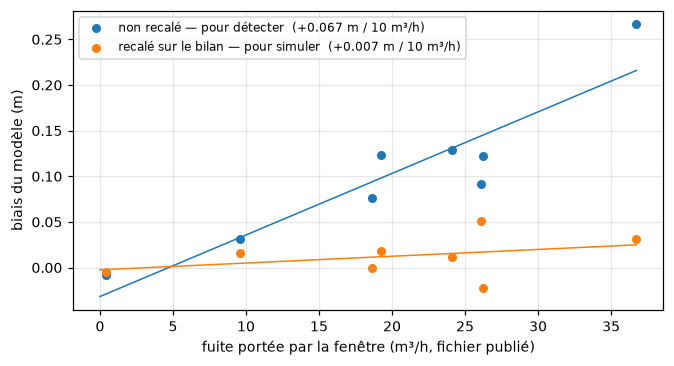

In [39]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
for col, lib in [("biais_non_recale", "non recalé — pour détecter"),
                 ("biais_recale", "recalé sur le bilan — pour simuler")]:
    pente, ordonnee = np.polyfit(essai.fuite_m3h, essai[col], 1)
    ax.scatter(essai.fuite_m3h, essai[col], s=24, label=f"{lib}  ({pente * 10:+.3f} m / 10 m³/h)")
    x = np.linspace(0, essai.fuite_m3h.max(), 10)
    ax.plot(x, pente * x + ordonnee, lw=1)
ax.set_xlabel("fuite portée par la fenêtre (m³/h, fichier publié)")
ax.set_ylabel("biais du modèle (m)")
ax.legend(fontsize=8); fig.tight_layout()

### Lecture

Le test répond sans ambiguïté. Le biais du modèle **non recalé** suit la charge de fuite : presque
nul sur la fenêtre saine de janvier, il monte nettement sur la fenêtre la plus fuyarde. Celui du
modèle **recalé** reste plat, quelle que soit la fuite : le recalage a déjà versé le volume
supplémentaire dans la demande des 690 nœuds, il n'en reste rien dans le résidu.

C'est le même réseau, les mêmes capteurs, les mêmes rugosités. Ce qui change est ce qu'on accepte
de laisser dans le résidu.

> **Un modèle de simulation et un modèle de détection ne sont pas le même objet.** Le recalage sur
> le bilan de masse donne le meilleur modèle hydraulique utilisable — cette eau circule réellement
> dans les conduites — et le pire détecteur, puisque la fuite se retrouve inscrite dans la demande.
> C'est une décision, pas un réglage.

## 10. Sur l'année entière

Une semaine de juillet ne prouve rien : on refait l'empilement sur les 105 120 pas de 2018.

L'occasion d'ajouter deux modèles qui **utilisent le fichier de fuites**, et ne sont donc pas
reproductibles sur une année ordinaire. Ils ne servent pas à calibrer, ils servent à savoir ce que
valent les deux autres.

| variante | demande de A+B | fuites dans le modèle | possible sans le fichier de fuites ? |
|---|---|---|---|
| détection | formes des compteurs × nominal | absentes | **oui** |
| détection, cible sans fuites | bilan − fuites publiées | absentes | non |
| simulation | bilan brut | diluées sur 690 nœuds | **oui** |
| fidèle | bilan − fuites publiées | **posées à leur conduite** | non |

Deux questions, une par modèle ajouté.

**La deuxième ligne** demande si le modèle de demande perd quelque chose face à la meilleure demande
sans fuite qu'on puisse construire — celle qui est recalée sur un instrument à chaque pas au lieu
d'être déduite. Si les deux se valent, le fichier de fuites n'apporte rien à la calibration, et la
ligne « détection » n'est pas un pis-aller : c'est l'optimum.

**La quatrième** remet tout ce qu'on sait de 2018 : la vraie demande et les vraies fuites, chacune
au bon endroit. Son erreur est le **plancher** — ce que le modèle ne saura pas expliquer même en
connaissant la réponse. Elle tranche la question que le §9 laisse ouverte : quand le modèle de
détection s'écarte de la mesure, est-ce la fuite qu'on voit, ou du bruit de modèle ?

In [40]:
# Une variante à la fois : chaque tableau de demande annuel pèse 330 Mo.
sans_fuite = sortie_ab - fuite_ab              # la consommation réelle de A+B, pas par pas

def demande(nom):
    if nom == "modèle livré":
        return P.demandes_nominales(wn, horo)[0]
    base = A.injecter_compteurs(D_annee, noeuds, ANNEE)
    if nom == "détection (compteurs seuls)":
        return base
    propre = A.recaler_zone_ab(base, noeuds, wn, ANNEE, cible=sans_fuite)
    if nom == "détection, cible sans fuites":
        return propre
    if nom == "simulation (bilan brut)":
        return A.recaler_zone_ab(base, noeuds, wn, ANNEE)
    return A.poser_fuites_publiees(propre, noeuds, wn, ANNEE)          # fidèle

sorties = {}
for nom in ["modèle livré", "détection (compteurs seuls)", "détection, cible sans fuites",
            "simulation (bilan brut)", "fidèle (fuites à leur conduite)"]:
    D = demande(nom)
    kw = {} if nom == "modèle livré" else dict(pompe=statut, niveau_mesure=niveau, coefficients=coefs)
    sorties[nom] = R.pressions_simulees(D[:R.PAS_AN + 1], noeuds, R.PAS_AN, tranche_jours=0.25,
                                        niveau0=float(niveau[0]), verbeux=False, **kw)
    del D
    print(f"{nom} : fait", flush=True)

annuel = G.tableau(sorties, p_mes)
print()
print(annuel[["biais_m", "dispersion_m", "rmse_m", "gain_dispersion", "gain_rmse"]].round(4).to_string())

modèle livré : fait


détection (compteurs seuls) : fait


détection, cible sans fuites : fait


simulation (bilan brut) : fait


fidèle (fuites à leur conduite) : fait



                                 biais_m  dispersion_m  rmse_m  gain_dispersion  gain_rmse
modèle livré                      0.3095        0.3890  0.4971           0.0000     0.0000
détection (compteurs seuls)       0.1538        0.2071  0.2579          -0.4677    -0.4811
détection, cible sans fuites      0.1563        0.2070  0.2594          -0.4678    -0.4781
simulation (bilan brut)           0.0140        0.1604  0.1610          -0.5876    -0.6761
fidèle (fuites à leur conduite)  -0.0126        0.0856  0.0865          -0.7799    -0.8259


In [41]:
plancher = annuel.loc["fidèle (fuites à leur conduite)", "dispersion_m"]
for nom in ["détection (compteurs seuls)", "simulation (bilan brut)"]:
    d = annuel.loc[nom, "dispersion_m"]
    print(f"{nom:32s} : dispersion {d:.4f} m, dont {plancher:.4f} de bruit de modèle "
          f"et {np.sqrt(max(d ** 2 - plancher ** 2, 0)):.4f} attribuable aux fuites")

détection (compteurs seuls)      : dispersion 0.2071 m, dont 0.0856 de bruit de modèle et 0.1885 attribuable aux fuites
simulation (bilan brut)          : dispersion 0.1604 m, dont 0.0856 de bruit de modèle et 0.1356 attribuable aux fuites


### Lecture

Les deux modèles ajoutés répondent chacun à leur question, et les deux réponses sont nettes.

**Le fichier de fuites n'apporte rien à la calibration.** Les lignes « détection » et « détection,
cible sans fuites » se départagent à la quatrième décimale. Recaler la demande de A+B sur un
instrument, à chaque pas, sur une cible débarrassée des fuites, ne fait pas mieux que de la déduire
des 82 compteurs de la zone C. Le modèle de demande n'est donc pas un pis-aller en attendant la
mesure : sur cette grandeur, **il est la mesure**.

**Le résidu du modèle de détection est bien la fuite.** Le modèle fidèle — même demande sans fuite,
mais les fuites publiées posées chacune à sa conduite — descend nettement plus bas que tous les
autres. C'est le plancher : ce que le modèle ne sait pas expliquer même en connaissant la réponse.
La décomposition quadratique au-dessus sépare, pour chaque modèle, ce qui est du bruit de modèle et
ce qui est du signal de fuite.

Et la comparaison des deux façons de traiter la **même eau** est sans appel. Diluée sur 690 nœuds
au prorata du nominal, elle laisse 0,1604 m de dispersion ; posée chacune à sa conduite, il n'en
reste que 0,0856. Même volume, même année, même réseau : **la moitié de l'erreur résiduelle du
modèle de simulation ne vient pas de la quantité d'eau, mais de son adresse.** C'est exactement ce
qui rend la localisation possible — et ce qui condamne un modèle qui répartit.

### Les rugosités sont ajustées sur deux jours. Tiennent-elles sur l'année ?

C'est la question qu'on doit à tout paramètre estimé par optimisation, et le §8 n'y a répondu qu'à
moitié : les deux fenêtres d'ajustement y étaient distantes de trois jours, toutes deux en janvier.
Coïncider à 0,7 unité sur deux fenêtres voisines ne prouve pas qu'on tiendra en décembre.

Le test franc demande deux simulations annuelles, et il faut le faire sur le modèle **fidèle** —
fuites posées à leur conduite. Sur le modèle de détection, le résidu contient 0,19 m de signal de
fuite qui masquerait complètement l'effet de la rugosité. Ici le résidu ne contient que de
l'erreur de modèle, donc ce qui bouge est bien attribuable aux coefficients.

On teste les coefficients **arrondis au dixième**, tels que le carnet les publie plus bas : c'est
ce qu'un lecteur recopierait, et cela vérifie au passage que l'arrondi ne coûte rien.

In [ ]:
# Deux simulations annuelles sur la même demande fidèle : rugosités du fichier, puis les treize
# ajustées sur les deux premiers jours de janvier. Environ six minutes chacune.
LIVRES = pd.Series(ajustement["coefficients"]).round(1).to_dict()
D_fid = A.poser_fuites_publiees(
    A.recaler_zone_ab(A.injecter_compteurs(D_annee, noeuds, ANNEE), noeuds, wn, ANNEE,
                      cible=sans_fuite), noeuds, wn, ANNEE)[:R.PAS_AN + 1]

duel = {}
for nom, kw in [("rugosités du fichier", {}),
                ("13 rugosités livrées", {"coefficients": U.coefficients_par_conduite(groupes, LIVRES)})]:
    duel[nom] = R.pressions_simulees(D_fid, noeuds, R.PAS_AN, tranche_jours=0.25,
                                     niveau0=float(niveau[0]), verbeux=False,
                                     pompe=statut, niveau_mesure=niveau, **kw)
del D_fid

print("année entière, modèle fidèle, 33 capteurs :")
print(G.tableau(duel, p_mes)[["biais_m", "dispersion_m", "rmse_m"]].round(4).to_string())

mois = pd.DatetimeIndex(horo[:R.PAS_AN]).month
par_mois = pd.DataFrame(
    {nom: [np.sqrt(np.nanmean((S - p_mes[:R.PAS_AN])[mois == m] ** 2)) for m in range(1, 13)]
     for nom, S in duel.items()}, index=[f"{m:02d}" for m in range(1, 13)])
par_mois["gain"] = par_mois.iloc[:, 1] / par_mois.iloc[:, 0] - 1
print("\nRMSE mois par mois (m) — janvier est la fenêtre d'ajustement :")
print(par_mois.round(4).to_string())

année entière, modèle fidèle, 33 capteurs :
                      biais_m  dispersion_m  rmse_m
rugosités du fichier   0.0968        0.1110  0.1473
13 rugosités livrées  -0.0127        0.0856  0.0865

RMSE mois par mois (m) — janvier est la fenêtre d'ajustement :
    rugosités du fichier  13 rugosités livrées    gain
01                0.0971                0.0602 -0.3801
02                0.1163                0.0688 -0.4084
03                0.1541                0.0843 -0.4531
04                0.1242                0.0760 -0.3878
05                0.1803                0.0959 -0.4680
06                0.1511                0.0930 -0.3842
07                0.1644                0.1002 -0.3907
08                0.1645                0.0983 -0.4026
09                0.1515                0.0920 -0.3928
10                0.1617                0.0935 -0.4217
11                0.1505                0.0876 -0.4177
12                0.1269                0.0771 -0.3922

### Lecture — aucun sur-ajustement, et la rugosité vaut mieux que ce que juillet laissait croire

**Le gain ne se dégrade pas d'un mois à l'autre.** Il vaut −38 % en janvier, la fenêtre
d'ajustement, et −39 % en décembre, onze mois plus tard. Le meilleur mois est mai (−47 %), le pire
est juin (−38 %) : le classement n'a aucun rapport avec la distance à janvier. Des coefficients
sur-ajustés donneraient l'inverse — un gain qui fond à mesure qu'on s'éloigne. Deux jours de
mesures suffisent donc à identifier treize coefficients qui décrivent **des conduites**, et non une
semaine. C'est la contrepartie directe du diagnostic du §8 : des groupes homogènes, où toutes les
conduites partagent la même valeur vraie, n'ont presque rien à sur-ajuster.

**Et l'effet est plus grand que ce que la semaine de juillet annonçait.** Le tableau d'étapes du §8
créditait la rugosité de −11 % de dispersion ; ici elle en retire **23 %** (0,1110 → 0,0856) et
supprime le biais (+0,097 → −0,013). La différence n'est pas une contradiction, c'est un effet de
masque : sur la semaine de juillet, le résidu contenait encore 11,9 m³/h de fuite, et cette fuite
occupait une partie de la dispersion que la rugosité ne pouvait pas réduire. Une fois les fuites
mises à leur place, ce que la rugosité corrige redevient visible.

> **Nuance à porter au §8, donc.** « L'ajustement agit presque exclusivement sur le biais » est vrai
> *mesuré sur une fenêtre qui fuit avec un modèle de détection*. Sur l'année et sur un modèle où les
> fuites sont comptabilisées, il agit sur les deux. Mesurer un levier dans un modèle où autre chose
> est encore faux le sous-estime — c'est la leçon n° 3 du carnet, qui s'applique ici à elle-même.

**Enfin, le chiffre publié.** La référence annonce 6 cm de RMSE, obtenus en ajustant six groupes sur
la première semaine de 2018 et en évaluant sur cette même semaine — donc dans l'échantillon, et sur
la seule semaine de l'année sans aucune fuite. Le tableau mensuel montre où se situe ce chiffre :

| | RMSE |
|---|---|
| janvier, le meilleur mois | 0,060 m |
| **moyenne annuelle** | **0,087 m** |
| juillet, le pire mois | 0,100 m |

**Les 6 cm sont un chiffre de janvier.** Ils ne sont pas faux, et on les reproduit — le modèle livré
sort à 0,058 m sur cette semaine-là. Mais ils décrivent le mois le plus froid, le moins consommateur
et le seul sans fuite. Sur l'année entière, fuites comptabilisées, le modèle tient **8,7 cm**, avec
une saisonnalité nette qui suit la demande : plus la consommation est forte, moins le modèle de
demande est sûr, et plus le résidu s'ouvre. C'est là qu'il reste du travail — pas dans la rugosité.

## 11. La livraison

Tout ce qui précède tient dans une fonction. La voici, sans dépendance à quoi que ce soit de ce
carnet, avec les treize coefficients en argument pour qu'elle serve telle quelle sur une autre
année.

In [42]:
def modele_calibre(wn, annee, coefficients, usage="detection", n_pas=None):
    '''Construit le modèle calibré : demandes par nœud et conditions aux limites.

    Renvoie (D, kw) où D est le tableau des demandes en m³/h (pas × jonctions) et kw les arguments
    de conditions aux limites à passer à `R.pressions_simulees` ou `R.simuler`.

    usage="detection" : la demande vient des compteurs et de l'équation (2) seulement, donc les
    fuites restent dans le résidu — c'est ce qu'il faut pour chercher une anomalie.
    usage="simulation" : la demande est recalée sur le bilan des débitmètres, ce qui donne les
    meilleures pressions mais dilue les fuites dans la demande des nœuds non mesurés.
    '''
    noeuds = wn.junction_name_list
    D, _ = P.demandes_calibrees(wn, annee, n_pas=n_pas)       # équations (1) et (2)
    D = A.injecter_compteurs(D, noeuds, annee)                # la mesure là où elle existe
    if usage == "simulation":
        D = A.recaler_zone_ab(D, noeuds, wn, annee)
    elif usage != "detection":
        raise ValueError(f"usage inconnu : {usage!r}")
    kw = dict(pompe=A.statut_pompe(annee),                    # l'état réel de la pompe
              niveau_mesure=R.charger_niveau(annee).to_numpy(),   # réancrage du réservoir
              coefficients=coefficients)                      # les rugosités ajustées
    return D, kw

In [43]:
# Vérification : la fonction reproduit bien la ligne « détection » du tableau annuel.
D_final, kw_final = modele_calibre(wn, ANNEE, coefs, usage="detection",
                                   n_pas=7 * R.PAS_JOUR + 1)
kw_final = {k: (v[:7 * R.PAS_JOUR + 1] if isinstance(v, np.ndarray) else v)
            for k, v in kw_final.items()}
S_final = R.pressions_simulees(D_final, noeuds, 7 * R.PAS_JOUR, tranche_jours=0.25,
                               niveau0=float(niveau[0]), verbeux=False, **kw_final)
print("modèle livré par la fonction, première semaine de 2018 :")
print(pd.Series(G.resume(S_final, p_mes[:7 * R.PAS_JOUR])).round(4).to_string())

print("\nles treize coefficients à conserver :")
print(pd.Series(ajustement["coefficients"]).round(1).to_string())

modèle livré par la fonction, première semaine de 2018 :
biais_m           -0.0028
dispersion_m       0.0577
rmse_m             0.0578
max_m              0.3552
n_pas           2016.0000

les treize coefficients à conserver :
AB|C120|D100           108.0
AB|C120|D150           108.0
AB|C120|D63            131.5
AB|C140|D100           129.5
AB|C140|D150           141.3
AB|C140|D160           151.3
AB|C140|D200           127.4
AB|C140|D225           147.7
AB|C140|D63            126.7
AB|C140|D75            126.0
C|C140|D100            126.7
C|C140|D200            154.0
frontiere|C140|D200    154.0


## Ce qu'il faut retenir

1. **Presque rien ne s'ajuste, presque tout se lit.** Des quatre étapes, une seule est une
   optimisation. Elle rapporte le moins sur une semaine — mais la mesure annuelle montre qu'elle
   rapporte beaucoup une fois les fuites mises à leur place. Avant d'ouvrir un optimiseur, faire
   d'abord l'inventaire de ce que les capteurs donnent déjà, puis mesurer le levier dans un modèle
   où le reste est juste.
2. **Le plus gros gain est le moins savant** : lire l'état de la pompe au débitmètre et réancrer le
   niveau du réservoir sur son capteur tient en deux arguments, et retire plus de dispersion que
   toute la décomposition des compteurs.
3. **Les gains ne s'additionnent pas, ils se composent.** Corriger la pompe rend le modèle de
   demande plus rentable qu'il ne le paraissait seul. Mesurer une amélioration dans un modèle où
   autre chose est encore faux sous-estime sa valeur.
4. **Séparer le biais de la dispersion change les conclusions — et il faut dire sur quelle
   fenêtre.** Sur la semaine de juillet, l'ajustement des rugosités agit presque exclusivement sur
   le biais et ne retire que 11 % de dispersion. Sur l'année entière et sur un modèle où les fuites
   sont comptabilisées, il en retire 23 % et supprime le biais. Le premier chiffre n'est pas faux,
   il est masqué : la fuite qui restait dans le résidu de juillet occupait une dispersion que la
   rugosité ne pouvait pas réduire.
5. **Un diagnostic d'une ligne vaut mieux qu'une optimisation de dix minutes.** La perte de charge
   médiane annonçait que la rugosité ne paierait pas ; le décompte des valeurs vraies par groupe
   annonçait qu'un découpage par diamètre ne pouvait pas converger.
6. **Régler sur une fenêtre sans fuite, évaluer sur une fenêtre qui fuit.** L'inverse fait acheter
   la fuite avec de la friction.
7. **Un paramètre estimé par optimisation demande deux vérifications** : que l'optimum soit
   intérieur, et que le régime simulé soit celui qu'on croit. La section du réservoir le montre : à l'échelle 1
   le critère a un minimum propre à 16 m, mais à 1,4 le réservoir sature la moitié de l'année et le
   critère ne mesure plus une section, il mesure un débordement.
8. **Le modèle de demande bâti sur 82 compteurs d'une zone prédit la consommation de 690 nœuds
   d'une autre zone à moins d'un pour cent** — et une cible mesurée ne fait pas mieux. C'était
   l'hypothèse la plus fragile de la méthode ; c'est devenu son résultat le plus solide.
9. **Là où la frontière est instrumentée, la soustraction bat la simulation.** Le bilan de masse de
   la zone C donne un débitmètre de fuite à 0,7 m³/h près, partout dans la zone, sans aucun modèle.
10. **Un chiffre de référence se lit avec sa fenêtre.** Les 6 cm publiés sont obtenus sur la
    première semaine de 2018 — la seule sans fuite, et le mois de plus faible consommation — en
    ajustant et en évaluant dessus. On les reproduit (0,058 m). Sur l'année entière, fuites
    comptabilisées, le même modèle tient 8,7 cm, de 6,0 en janvier à 10,0 en juillet. Ce qui reste
    à corriger est saisonnier et suit la demande, pas la friction.
11. **Il faut choisir ce que le résidu doit contenir.** Simuler et détecter demandent deux modèles,
    et c'est une décision, pas un réglage.